In [1]:
% setup environment
% clear data and number format
clear; format short e
% set path to equilibrium solver
txt=pwd; n=length(txt); rootpath=txt;
n=strfind(rootpath,"USERS"); rootpath=txt(1:n-2);
PHREEQCpath=[rootpath,'/runPHREEQC']
addpath(PHREEQCpath);
JEQUILIBpath=[rootpath,'/JEQUILIB'];
addpath(JEQUILIBpath);
% turn off warnings
warning off
%graphics_toolkit ("notebook"); 
%graphics_toolkit ("plotly"); 
graphics_toolkit("gnuplot")
% delete phreeqcrunfile
%system("rm porttest.txt");
%system('export PATH="$PATH:PHREEQCpath"')
%system('phreeqc')


PHREEQCpath = /home/jupyter/DrSmith/GeochemEquilib/runPHREEQC


In [2]:
database=['llnl.dat'];

In [3]:
% variables

% amounts
XP=0.020; XPstr=num2str(XP);
XC=1e-6; XCstr=num2str(XC);
XW=0.0011; XWstr=num2str(XW);
logPCO2=-3.3;   % PCO2. measured at 468.4 ppm average in the room 
logPCO2str=num2str(logPCO2);

% Ksp values
KspP=0.00000660693; KspPstr=num2str(KspP); % from https://www.aqion.de/site/16 0.00000660693
KspC=10^-8.48; KspCstr=num2str(KspC); % for calcite from aquaion 
KspW=10^3.4; KspWstr=num2str(KspW); %google AI reported the value. combine with SiO3+H=HSiO3 Ka value

% rate constants

kP=9e-1; kPstr=num2str(kP); %port dissoltuion
kC=0.04e-2;  kCstr=num2str(kC); %calciate ppte
kCO2=0.63e-3; kCO2str=num2str(kCO2); % gas transfer
kW=3e-1; kWstr=num2str(kW); %wollastonite solubility rate

% time vector
logtime=0.05:0.05:2.2; time=[10.^logtime];
%timetry=[0.00 0.10 2.00 24.00 48.00 72.00 96.00 144.00]; time=timetry;

In [4]:
solutionboxtext=[...
{'SOLUTION 1\n'}
{'       pe      13.75\n'}
{'       pH      5.65\n'}
{'       temp    25\n'}
{'-units mol/kgw\n'}
   ];
[nolinesSOLN,length]=size(solutionboxtext);

In [5]:
rateboxtext=[...
{'RATES\n'}

{'Portlandite\n'}
{'-start\n'}
{'1   REM   PARM(1) = rate constant. PARM(2) Ksp for portlandite \n'}
{'2 Ca=Act("Ca+2")\n'}
{'3 OH=Act("OH-")\n'}
{'4 IAP=Ca*OH^2\n'}
{'5 Ksp=PARM(2)\n'}
{'6 si_pp=log(IAP/Ksp)\n'}
{'20  IF (M <= 0  and si_pp < 0) THEN GOTO 200\n'}
{'120 rate = PARM(1) *M* (1 - (10^(si_pp))^0.48)\n'}
{'140 moles = rate*TIME\n'}
{'200 SAVE moles\n'}
{'   -end\n'}

{'Calcite\n'}
{'-start\n'}
{'-start\n'}
{'1   REM   PARM(1) = rate constant. Parm(2)=Ksp calcite\n'}
{'2 Ca=Act("Ca+2")\n'}
{'3 CO3=Act("CO3-2")\n'}
{'4 IAP=Ca*CO3\n'}
{'5 Ksp=PARM(2)\n'}
{'6 si_cc=log(IAP/Ksp)\n'}
{'20  IF (M <= 0  and si_cc < 0) THEN GOTO 200\n'}
{'120 rate = PARM(1) *M* (1 - (10^(si_cc))^0.48)\n'}
{'140 moles = rate*TIME\n'}
{'200 SAVE moles\n'}
{'   -end\n'}

{'Wollastonite\n'}
{'-start\n'}
{'1   REM   PARM(1) = rate constant. Parm(2)=Ksp Wollastonite\n'}
{'2 Ca=Act("Ca+2")\n'}
{'3 HSiO3=Act("HSiO3-")\n'}
{'4 H=Act("H+")\n'}
{'5 IAP=(Ca*HSiO3)/H \n'}
{'6 Ksp=PARM(2)\n'}
{'7 si_ww=log(IAP/Ksp)\n'}
{'20  IF (M <= 0  and si_cc < 0) THEN GOTO 200\n'}
{'120 rate = PARM(1) *M* (1 - (10^(si_ww)))\n'}
{'140 moles = rate*TIME\n'}
{'200 SAVE moles\n'}
{'   -end\n'}

{'CO2_dissolution\n'}
{'-start\n'}
{'20 k = parm(2)\n'}
{'30 eq_HCO3 = 10^PARM(1)*10^LK_PHASE("CO2(g)")/ACT("H+")\n'}
{'40 act_HCO3 = ACT("HCO3-")\n'}
{'50 moles = k * (1-(act_HCO3/eq_HCO3)^0.2) * TIME\n'}
{'60 SAVE moles\n'}
{'   -end\n'}
];
[nolinesRATE,length]=size(rateboxtext);

In [6]:
m0Pline=['  -m0    ',XPstr,'\n'];
mPline=['  -m    ',XPstr,'\n'];
parmsPline=['  -parms ',kPstr,' ',KspPstr,'\n'];

m0Cline=['  -m0    ',XCstr,'\n'];
mCline=['  -m    ',XCstr,'\n'];
parmsCline=['  -parms ',kCstr,' ',KspCstr,'\n'];

m0Wline=['  -m0    ',XWstr,'\n'];
mWline=['  -m    ',XWstr,'\n'];
parmsWline=['  -parms ',kWstr,' ',KspWstr,'\n'];

parmsCO2line=['  -parms ',logPCO2str,' ',kCO2str,'\n'];
timestr=mat2str([0 time]); timestr = regexprep(timestr,'\[','');  timestr = regexprep(timestr,'\]','');
timeline=[' -steps ',timestr,' s\n'];

kineticsboxtext=[...
{'KINETICS 1\n'}

{'Portlandite\n'}
{'  -tol   1e-13\n'}
{m0Pline}
{mPline}
{parmsPline}

{'Calcite\n'}
{'  -tol   1e-13\n'}
{m0Cline}
{mCline}
{parmsCline}

{'Wollastonite\n'}
{'  -tol   1e-13\n'}
{m0Wline}
{mWline}
{parmsWline}

{'CO2_dissolution\n'}
{'  -tol   1e-13\n'}
{'-formula CO2 1\n'}
{parmsCO2line}
{timeline}

{'  -cvode\n'}
{'-runge_kutta      6\n'}
];

[nolinesKIN,length]=size(kineticsboxtext);

In [7]:
selectboxtext=[...
{' SELECTED_OUTPUT\n'}
{' -file portout.txt\n'}
{' -selected_out true\n'}
{' -user_punch true\n'}
{' -high_precision true\n'}
{' -reset false\n'}
{' -simulation false\n'}
{' -state false\n'}
{' -distance false\n'}
{' -time false\n'}
{' -step false\n'}
{' -ph false\n'}
{' -pe false\n'}
{' -reaction false\n'}
{' -temperature false\n'}
{' -alkalinity false\n'}
{' -ionic_strength false\n'}
{' -water false\n'}
{' -charge_balance false\n'}
{' -percent_error false\n'}
];
[nolinesSEL,length]=size(selectboxtext);

In [8]:
punchboxtext=[...
{'USER_PUNCH\n'}
{'        -headings seconds  Ca  pH Calcite  Portlandite DIC Si\n'}
{'  10 PUNCH SIM_TIME, TOT("Ca"), -LA("H+"), KIN("Calcite"), KIN("Portlandite"), TOT("C"), TOT("Si") \n'}
];
[nolinesPUNCH,length]=size(punchboxtext);

In [9]:
fileID=fopen('porttest.txt','w');

fprintf(fileID,'TITLE TEST PORTLANDITE DISSOLUTION\n');

for i=1:nolinesSOLN
    line=cell2mat(solutionboxtext(i,:));
    fprintf(fileID,line)
end
fprintf(fileID,'\n');
for i=1:nolinesRATE
    line=cell2mat(rateboxtext(i,:));
    fprintf(fileID,line)
end
fprintf(fileID,'\n');
for i=1:nolinesKIN
    line=cell2mat(kineticsboxtext(i,:));
    fprintf(fileID,line)
end
fprintf(fileID,'\n');
for i=1:nolinesSEL
    line=cell2mat(selectboxtext(i,:));
    fprintf(fileID,line)
end
fprintf(fileID,'\n');
for i=1:nolinesPUNCH
    line=cell2mat(punchboxtext(i,:));
    fprintf(fileID,line)
end
fprintf(fileID,'\n');
fprintf(fileID,'END');
fclose(fileID);

In [10]:
str=['system("/home/jupyter/DrSmith/GeochemEquilib/runPHREEQC/phreeqc porttest.txt out.txt ', database,'");'];
eval(str); % output to the screen
%evalc(str); % so no screen output
fid = fopen('portout.txt','rt');
hdr = strtrim(regexp(fgetl(fid),'\t','split'));
hdr=hdr(1:7)';
mat = cell2mat(textscan(fid,repmat('%f',1,numel(hdr))));
[nsize,msize]=size(mat);
time=mat(2:nsize,1); Caphreeqc=mat(2:nsize,2); pHphreeqc=mat(2:nsize,3);
calcitephreeqc=mat(2:nsize,4); portlanditephreeqc=mat(2:nsize,5);
DIC=mat(2:nsize,6); Siaq=mat(2:nsize,7);

Input file: porttest.txt

Output file: out.txt

Database file: llnl.dat


Initializing...                                                                 







Simulation 1. Kinetic step 2.                                                  









Simulation 1. Kinetic step 3.                                                  









Simulation 1. Kinetic step 4.                                                  









Simulation 1. Kinetic step 5.                                                  









Simulation 1. Kinetic step 6.                                                  







Simulation 1. Kinetic step 7.                                                  











Simulation 1. Kinetic step 7.                                                  







Simulation 1. Kinetic step 8.                                                  









Simulation 1. Kinetic step 9.                                                  









Simulation 1. Kinetic step 10.         

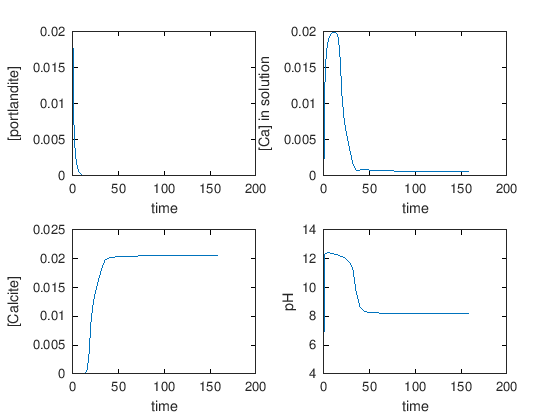

In [11]:

subplot(221); plot(time,portlanditephreeqc); ylabel('[portlandite]'); xlabel('time')
subplot(222); plot(time,Caphreeqc); ylabel('[Ca] in solution'); xlabel('time')
subplot(223); plot(time,calcitephreeqc); ylabel('[Calcite]'); xlabel('time')
subplot(224); plot(time,pHphreeqc); ylabel('pH'); xlabel('time')



In [12]:
% data
%6 g cement small size

data=[...
%Sampling times (H)	pH	DIC (mmol/L)	Conductivity (us/cm)	Ca2+ (mmol/L)	Si (mmol/L)
0.00	4.44	-0.06	NaN	0.101	0.006
0.10	9.62	0.54	88.2	0.309	0.048
2.00	8.62	0.70	78.3	0.385	0.18
24.00	8.07	1.38	155.9	0.784	0.276
48.00	8.04	1.49	168.1	0.7941	0.292
72.00	8.09	1.40	181.9	0.756575	0.299

];

sampletime=data(:,1); samplepH=data(:,2); sampleDIC=(data(:,3)*1e-3); conduct=data(:,4); sampleCa=(data(:,5)*1e-3); 
sampleSi=(data(:,6)*1e-3);


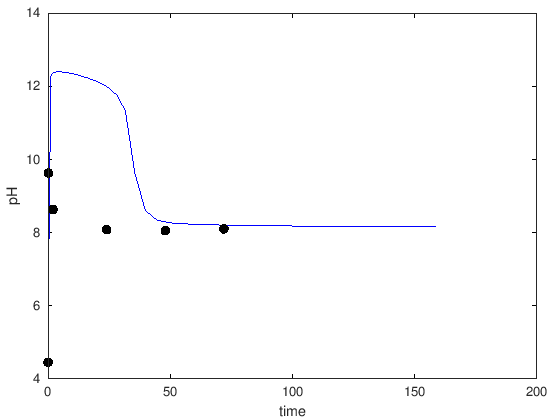

In [13]:
plot(time,pHphreeqc,'b-','linewidth',2); ylabel('pH'); xlabel('time')
hold on
%plot(timeres,pHres,'bo')
plot(sampletime,samplepH,'ko','markersize',8,'markerfacecolor','k')
set(gca,'linewidth',2)

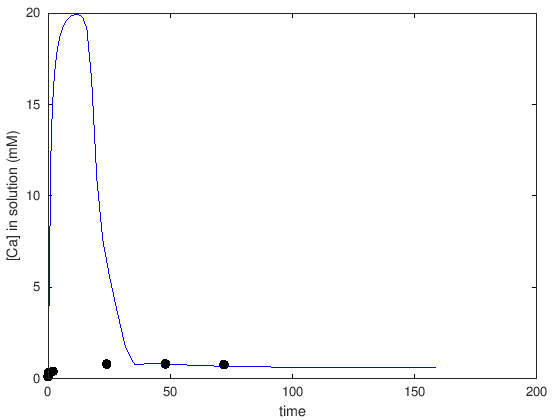

In [14]:
plot(time,(Caphreeqc*1e3),'b-','linewidth',2); ylabel('[Ca] in solution (mM)'); xlabel('time')
hold on
plot(sampletime,(sampleCa*1e3),'ko','markersize',8,'markerfacecolor','k')
set(gca,'linewidth',2)

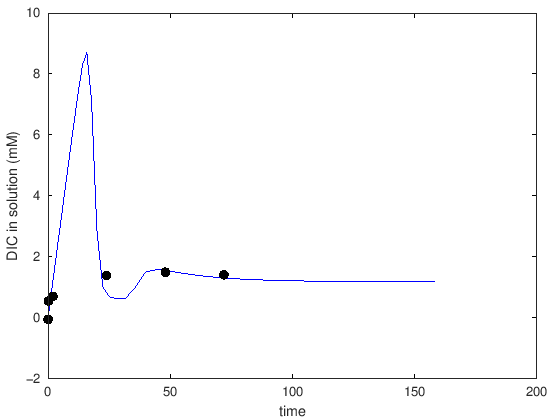

In [15]:
plot(time,1e3*DIC,'b-','linewidth',2); ylabel('DIC in solution (mM)'); xlabel('time')
hold on
plot(sampletime,sampleDIC*1e3,'ko','markersize',8,'markerfacecolor','k')
set(gca,'linewidth',2)

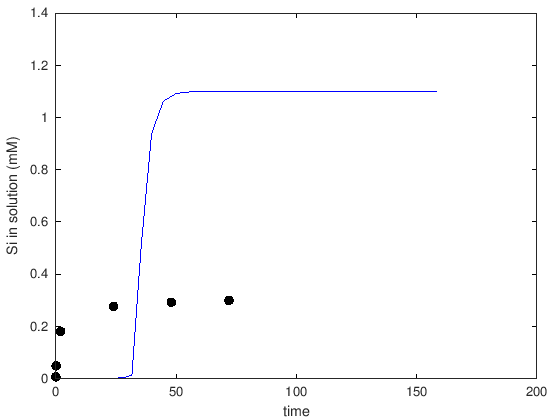

In [16]:
plot(time,1e3*(Siaq),'b-','linewidth',2); ylabel('Si in solution (mM)'); xlabel('time')
hold on
plot(sampletime,sampleSi*1e3,'ko','markersize',8,'markerfacecolor','k')
set(gca,'linewidth',2)

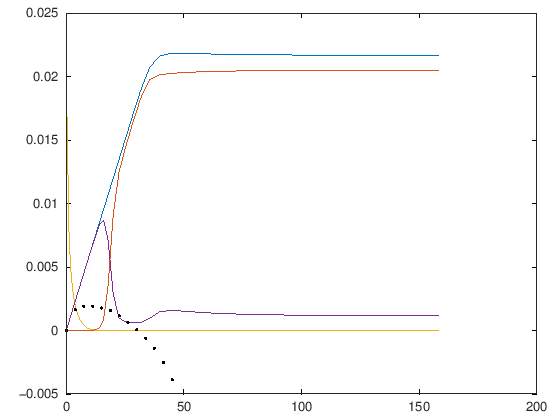

In [18]:
% plot total C that ends up in solution

CTsoln=DIC+calcitephreeqc;

%plot(time,CTsoln,time,calcite,time,port,time,DIC,sampletime,sampleDIC,'r.')
plot(time,CTsoln,time,calcitephreeqc,time,portlanditephreeqc,time,DIC,'linewidth',2)


data=[...
%Time (min)	Time(h)	Carbon dioxide(ppm)		CO2_input (mol)	CO2_out (mol)	△ CO2 consumed (mol)	CO2 capture rate （umol/5 min）	CO2 capture rate （umol/h）	CO2 capture （umol）
0	0.00	495.00	5.9813E-05	5.8846E-05	9.6667E-07	9.6667E-01	1.1600E+01	9.6667E-01
4.9998	0.08	487.00	5.9813E-05	5.8121E-05	1.6917E-06	1.6917E+00	2.0300E+01	2.6583E+00
10.0002	0.17	481.00	5.9813E-05	2.7429E-05	3.2383E-05	3.2383E+01	3.8860E+02	3.5042E+01
15	0.25	227.00	5.9813E-05	1.8125E-05	4.1688E-05	4.1688E+01	5.0025E+02	7.6729E+01
19.9998	0.33	150.00	5.9813E-05	1.6433E-05	4.3379E-05	4.3379E+01	5.2055E+02	1.2011E+02
25.0002	0.42	136.00	5.9813E-05	1.0875E-05	4.8938E-05	4.8938E+01	5.8725E+02	1.6905E+02
30	0.50	90.00	5.9813E-05	1.1842E-05	4.7971E-05	4.7971E+01	5.7565E+02	2.1702E+02
34.9998	0.58	98.00	5.9813E-05	1.0996E-05	4.8817E-05	4.8817E+01	5.8580E+02	2.6583E+02
40.0002	0.67	91.00	5.9813E-05	1.1721E-05	4.8092E-05	4.8092E+01	5.7710E+02	3.1393E+02
45	0.75	97.00	5.9813E-05	1.1721E-05	4.8092E-05	4.8092E+01	5.7710E+02	3.6202E+02
49.9998	0.83	97.00	5.9813E-05	1.0875E-05	4.8938E-05	4.8938E+01	5.8725E+02	4.1095E+02
55.0002	0.92	90.00	5.9813E-05	1.3171E-05	4.6642E-05	4.6642E+01	5.5970E+02	4.5760E+02
60	1.00	109.00	5.9813E-05	1.3413E-05	4.6400E-05	4.6400E+01	5.5680E+02	5.0400E+02
64.9998	1.08	111.00	5.9813E-05	1.1117E-05	4.8696E-05	4.8696E+01	5.8435E+02	5.5269E+02
70.0002	1.17	92.00	5.9813E-05	1.3171E-05	4.6642E-05	4.6642E+01	5.5970E+02	5.9933E+02
75	1.25	109.00	5.9813E-05	1.1358E-05	4.8454E-05	4.8454E+01	5.8145E+02	6.4779E+02
79.9998	1.33	94.00	5.9813E-05	1.3050E-05	4.6763E-05	4.6763E+01	5.6115E+02	6.9455E+02
85.0002	1.42	108.00	5.9813E-05	1.3050E-05	4.6763E-05	4.6763E+01	5.6115E+02	7.4131E+02
90	1.50	108.00	5.9813E-05	1.2688E-05	4.7125E-05	4.7125E+01	5.6550E+02	7.8844E+02
94.9998	1.58	105.00	5.9813E-05	1.4500E-05	4.5313E-05	4.5313E+01	5.4375E+02	8.3375E+02
100.0002	1.67	120.00	5.9813E-05	1.3654E-05	4.6158E-05	4.6158E+01	5.5390E+02	8.7991E+02
105	1.75	113.00	5.9813E-05	1.4379E-05	4.5433E-05	4.5433E+01	5.4520E+02	9.2534E+02
109.9998	1.83	119.00	5.9813E-05	1.5829E-05	4.3983E-05	4.3983E+01	5.2780E+02	9.6933E+02
115.0002	1.92	131.00	5.9813E-05	1.6796E-05	4.3017E-05	4.3017E+01	5.1620E+02	1.0123E+03
120	2.00	139.00	5.9813E-05	1.7038E-05	4.2775E-05	4.2775E+01	5.1330E+02	1.0551E+03
124.9998	2.08	141.00	5.9813E-05	1.6675E-05	4.3138E-05	4.3138E+01	5.1765E+02	1.0983E+03
130.0002	2.17	138.00	5.9813E-05	1.6433E-05	4.3379E-05	4.3379E+01	5.2055E+02	1.1416E+03
135	2.25	136.00	5.9813E-05	1.8729E-05	4.1083E-05	4.1083E+01	4.9300E+02	1.1827E+03
139.9998	2.33	155.00	5.9813E-05	1.9575E-05	4.0238E-05	4.0238E+01	4.8285E+02	1.2230E+03
145.0002	2.42	162.00	5.9813E-05	2.3563E-05	3.6250E-05	3.6250E+01	4.3500E+02	1.2592E+03
150	2.50	195.00	5.9813E-05	2.4046E-05	3.5767E-05	3.5767E+01	4.2920E+02	1.2950E+03
154.9998	2.58	199.00	5.9813E-05	2.5738E-05	3.4075E-05	3.4075E+01	4.0890E+02	1.3290E+03
160.0002	2.67	213.00	5.9813E-05	2.8033E-05	3.1779E-05	3.1779E+01	3.8135E+02	1.3608E+03
165	2.75	232.00	5.9813E-05	3.0692E-05	2.9121E-05	2.9121E+01	3.4945E+02	1.3899E+03
169.9998	2.83	254.00	5.9813E-05	3.2383E-05	2.7429E-05	2.7429E+01	3.2915E+02	1.4174E+03
175.0002	2.92	268.00	5.9813E-05	3.5042E-05	2.4771E-05	2.4771E+01	2.9725E+02	1.4421E+03
180	3.00	290.00	5.9813E-05	3.6250E-05	2.3563E-05	2.3563E+01	2.8275E+02	1.4657E+03
184.9998	3.08	300.00	5.9813E-05	3.5646E-05	2.4167E-05	2.4167E+01	2.9000E+02	1.4899E+03
190.0002	3.17	295.00	5.9813E-05	4.0963E-05	1.8850E-05	1.8850E+01	2.2620E+02	1.5087E+03
195	3.25	339.00	5.9813E-05	3.7821E-05	2.1992E-05	2.1992E+01	2.6390E+02	1.5307E+03
199.9998	3.33	313.00	5.9813E-05	4.4346E-05	1.5467E-05	1.5467E+01	1.8560E+02	1.5462E+03
205.0002	3.42	367.00	5.9813E-05	4.3863E-05	1.5950E-05	1.5950E+01	1.9140E+02	1.5621E+03
210	3.50	363.00	5.9813E-05	4.3742E-05	1.6071E-05	1.6071E+01	1.9285E+02	1.5782E+03
214.9998	3.58	362.00	5.9813E-05	4.3138E-05	1.6675E-05	1.6675E+01	2.0010E+02	1.5949E+03
220.0002	3.67	357.00	5.9813E-05	4.5554E-05	1.4258E-05	1.4258E+01	1.7110E+02	1.6091E+03
225	3.75	377.00	5.9813E-05	4.5433E-05	1.4379E-05	1.4379E+01	1.7255E+02	1.6235E+03
229.9998	3.83	376.00	5.9813E-05	4.6883E-05	1.2929E-05	1.2929E+01	1.5515E+02	1.6364E+03
235.0002	3.92	388.00	5.9813E-05	4.8213E-05	1.1600E-05	1.1600E+01	1.3920E+02	1.6480E+03
240	4.00	399.00	5.9813E-05	4.8333E-05	1.1479E-05	1.1479E+01	1.3775E+02	1.6595E+03
244.9998	4.08	400.00	5.9813E-05	4.8938E-05	1.0875E-05	1.0875E+01	1.3050E+02	1.6704E+03
250.0002	4.17	405.00	5.9813E-05	4.9783E-05	1.0029E-05	1.0029E+01	1.2035E+02	1.6804E+03
255	4.25	412.00	5.9813E-05	5.0025E-05	9.7875E-06	9.7875E+00	1.1745E+02	1.6902E+03
259.9998	4.33	414.00	5.9813E-05	5.1233E-05	8.5792E-06	8.5792E+00	1.0295E+02	1.6988E+03
265.0002	4.42	424.00	5.9813E-05	5.0267E-05	9.5458E-06	9.5458E+00	1.1455E+02	1.7083E+03
270	4.50	416.00	5.9813E-05	5.2200E-05	7.6125E-06	7.6125E+00	9.1350E+01	1.7160E+03
274.9998	4.58	432.00	5.9813E-05	5.1233E-05	8.5792E-06	8.5792E+00	1.0295E+02	1.7245E+03
280.0002	4.67	424.00	5.9813E-05	5.1717E-05	8.0958E-06	8.0958E+00	9.7150E+01	1.7326E+03
285	4.75	428.00	5.9813E-05	5.0750E-05	9.0625E-06	9.0625E+00	1.0875E+02	1.7417E+03
289.9998	4.83	420.00	5.9813E-05	5.3529E-05	6.2833E-06	6.2833E+00	7.5400E+01	1.7480E+03
295.0002	4.92	443.00	5.9813E-05	5.3288E-05	6.5250E-06	6.5250E+00	7.8300E+01	1.7545E+03
300	5.00	441.00	5.9813E-05	5.4013E-05	5.8000E-06	5.8000E+00	6.9600E+01	1.7603E+03
304.9998	5.08	447.00	5.9813E-05	5.2925E-05	6.8875E-06	6.8875E+00	8.2650E+01	1.7672E+03
310.0002	5.17	438.00	5.9813E-05	5.3650E-05	6.1625E-06	6.1625E+00	7.3950E+01	1.7734E+03
315	5.25	444.00	5.9813E-05	5.5342E-05	4.4708E-06	4.4708E+00	5.3650E+01	1.7778E+03
319.9998	5.33	458.00	5.9813E-05	5.4858E-05	4.9542E-06	4.9542E+00	5.9450E+01	1.7828E+03
325.0002	5.42	454.00	5.9813E-05	5.4133E-05	5.6792E-06	5.6792E+00	6.8150E+01	1.7885E+03
330	5.50	448.00	5.9813E-05	5.6550E-05	3.2625E-06	3.2625E+00	3.9150E+01	1.7917E+03
334.9998	5.58	468.00	5.9813E-05	5.3892E-05	5.9208E-06	5.9208E+00	7.1050E+01	1.7976E+03
340.0002	5.67	446.00	5.9813E-05	5.4858E-05	4.9542E-06	4.9542E+00	5.9450E+01	1.8026E+03
345	5.75	454.00	5.9813E-05	5.2079E-05	7.7333E-06	7.7333E+00	9.2800E+01	1.8103E+03
349.9998	5.83	431.00	5.9813E-05	5.3771E-05	6.0417E-06	6.0417E+00	7.2500E+01	1.8164E+03
355.0002	5.92	445.00	5.9813E-05	5.3771E-05	6.0417E-06	6.0417E+00	7.2500E+01	1.8224E+03
360	6.00	445.00	5.9813E-05	5.4013E-05	5.8000E-06	5.8000E+00	6.9600E+01	1.8282E+03
364.9998	6.08	447.00	5.9813E-05	5.4738E-05	5.0750E-06	5.0750E+00	6.0900E+01	1.8333E+03
370.0002	6.17	453.00	5.9813E-05	5.4738E-05	5.0750E-06	5.0750E+00	6.0900E+01	1.8384E+03
375	6.25	453.00	5.9813E-05	5.2925E-05	6.8875E-06	6.8875E+00	8.2650E+01	1.8452E+03
379.9998	6.33	438.00	5.9813E-05	5.4013E-05	5.8000E-06	5.8000E+00	6.9600E+01	1.8510E+03
385.0002	6.42	447.00	5.9813E-05	5.5463E-05	4.3500E-06	4.3500E+00	5.2200E+01	1.8554E+03
390	6.50	459.00	5.9813E-05	5.4254E-05	5.5583E-06	5.5583E+00	6.6700E+01	1.8610E+03
394.9998	6.58	449.00	5.9813E-05	5.6067E-05	3.7458E-06	3.7458E+00	4.4950E+01	1.8647E+03
400.0002	6.67	464.00	5.9813E-05	5.5704E-05	4.1083E-06	4.1083E+00	4.9300E+01	1.8688E+03
405	6.75	461.00	5.9813E-05	5.4738E-05	5.0750E-06	5.0750E+00	6.0900E+01	1.8739E+03
409.9998	6.83	453.00	5.9813E-05	5.5342E-05	4.4708E-06	4.4708E+00	5.3650E+01	1.8784E+03
415.0002	6.92	458.00	5.9813E-05	5.4617E-05	5.1958E-06	5.1958E+00	6.2350E+01	1.8836E+03
420	7.00	452.00	5.9813E-05	5.5100E-05	4.7125E-06	4.7125E+00	5.6550E+01	1.8883E+03
424.9998	7.08	456.00	5.9813E-05	5.6792E-05	3.0208E-06	3.0208E+00	3.6250E+01	1.8913E+03
430.0002	7.17	470.00	5.9813E-05	5.6913E-05	2.9000E-06	2.9000E+00	3.4800E+01	1.8942E+03
435	7.25	471.00	5.9813E-05	5.5704E-05	4.1083E-06	4.1083E+00	4.9300E+01	1.8983E+03
439.9998	7.33	461.00	5.9813E-05	5.7154E-05	2.6583E-06	2.6583E+00	3.1900E+01	1.9010E+03
445.0002	7.42	473.00	5.9813E-05	5.6308E-05	3.5042E-06	3.5042E+00	4.2050E+01	1.9045E+03
450	7.50	466.00	5.9813E-05	5.4133E-05	5.6792E-06	5.6792E+00	6.8150E+01	1.9101E+03
454.9998	7.58	448.00	5.9813E-05	5.7758E-05	2.0542E-06	2.0542E+00	2.4650E+01	1.9122E+03
460.0002	7.67	478.00	5.9813E-05	5.7638E-05	2.1750E-06	2.1750E+00	2.6100E+01	1.9144E+03
465	7.75	477.00	5.9813E-05	5.8000E-05	1.8125E-06	1.8125E+00	2.1750E+01	1.9162E+03
469.9998	7.83	480.00	5.9813E-05	5.8000E-05	1.8125E-06	1.8125E+00	2.1750E+01	1.9180E+03
475.0002	7.92	480.00	5.9813E-05	5.8725E-05	1.0875E-06	1.0875E+00	1.3050E+01	1.9191E+03
480	8.00	486.00	5.9813E-05	5.8242E-05	1.5708E-06	1.5708E+00	1.8850E+01	1.9206E+03
484.9998	8.08	482.00	5.9813E-05	5.8725E-05	1.0875E-06	1.0875E+00	1.3050E+01	1.9217E+03
490.0002	8.17	486.00	5.9813E-05	5.6550E-05	3.2625E-06	3.2625E+00	3.9150E+01	1.9250E+03
495	8.25	468.00	5.9813E-05	5.7638E-05	2.1750E-06	2.1750E+00	2.6100E+01	1.9272E+03
499.9998	8.33	477.00	5.9813E-05	5.9088E-05	7.2500E-07	7.2500E-01	8.7000E+00	1.9279E+03
505.0002	8.42	489.00	5.9813E-05	6.0417E-05	-6.0417E-07	-6.0417E-01	-7.2500E+00	1.9273E+03
510	8.50	500.00	5.9813E-05	5.5946E-05	3.8667E-06	3.8667E+00	4.6400E+01	1.9312E+03
514.9998	8.58	463.00	5.9813E-05	5.8483E-05	1.3292E-06	1.3292E+00	1.5950E+01	1.9325E+03
520.0002	8.67	484.00	5.9813E-05	5.9571E-05	2.4167E-07	2.4167E-01	2.9000E+00	1.9327E+03
525	8.75	493.00	5.9813E-05	5.6308E-05	3.5042E-06	3.5042E+00	4.2050E+01	1.9362E+03
529.9998	8.83	466.00	5.9813E-05	6.0417E-05	-6.0417E-07	-6.0417E-01	-7.2500E+00	1.9356E+03
535.0002	8.92	500.00	5.9813E-05	5.8967E-05	8.4583E-07	8.4583E-01	1.0150E+01	1.9365E+03
540	9.00	488.00	5.9813E-05	5.9933E-05	-1.2083E-07	-1.2083E-01	-1.4500E+00	1.9364E+03
544.9998	9.08	496.00	5.9813E-05	5.8604E-05	1.2083E-06	1.2083E+00	1.4500E+01	1.9376E+03
550.0002	9.17	485.00	5.9813E-05	5.8604E-05	1.2083E-06	1.2083E+00	1.4500E+01	1.9388E+03
555	9.25	485.00	5.9813E-05	6.1867E-05	-2.0542E-06	-2.0542E+00	-2.4650E+01	1.9367E+03
559.9998	9.33	512.00	5.9813E-05	5.9571E-05	2.4167E-07	2.4167E-01	2.9000E+00	1.9370E+03
565.0002	9.42	493.00	5.9813E-05	5.9208E-05	6.0417E-07	6.0417E-01	7.2500E+00	1.9376E+03
570	9.50	490.00	5.9813E-05	5.9450E-05	3.6250E-07	3.6250E-01	4.3500E+00	1.9379E+03
574.9998	9.58	492.00	5.9813E-05	6.0658E-05	-8.4583E-07	-8.4583E-01	-1.0150E+01	1.9371E+03
580.0002	9.67	502.00	5.9813E-05	5.8363E-05	1.4500E-06	1.4500E+00	1.7400E+01	1.9385E+03
585	9.75	483.00	5.9813E-05	5.9088E-05	7.2500E-07	7.2500E-01	8.7000E+00	1.9393E+03
589.9998	9.83	489.00	5.9813E-05	5.9571E-05	2.4167E-07	2.4167E-01	2.9000E+00	1.9395E+03
595.0002	9.92	493.00	5.9813E-05	5.9813E-05	0.0000E+00	0.0000E+00	0.0000E+00	1.9395E+03
600	10.00	495.00	5.9813E-05	5.9571E-05	2.4167E-07	2.4167E-01	2.9000E+00	1.9397E+03
604.9998	10.08	493.00	5.9813E-05	6.1867E-05	-2.0542E-06	-2.0542E+00	-2.4650E+01	1.9377E+03
610.0002	10.17	512.00	5.9813E-05	6.0296E-05	-4.8333E-07	-4.8333E-01	-5.8000E+00	1.9372E+03
615	10.25	499.00	5.9813E-05	5.8242E-05	1.5708E-06	1.5708E+00	1.8850E+01	1.9388E+03
619.9998	10.33	482.00	5.9813E-05	5.9933E-05	-1.2083E-07	-1.2083E-01	-1.4500E+00	1.9387E+03
625.0002	10.42	496.00	5.9813E-05	6.2713E-05	-2.9000E-06	-2.9000E+00	-3.4800E+01	1.9358E+03
630	10.50	519.00	5.9813E-05	6.0658E-05	-8.4583E-07	-8.4583E-01	-1.0150E+01	1.9349E+03
634.9998	10.58	502.00	5.9813E-05	6.1383E-05	-1.5708E-06	-1.5708E+00	-1.8850E+01	1.9333E+03
640.0002	10.67	508.00	5.9813E-05	6.0417E-05	-6.0417E-07	-6.0417E-01	-7.2500E+00	1.9327E+03
645	10.75	500.00	5.9813E-05	6.0296E-05	-4.8333E-07	-4.8333E-01	-5.8000E+00	1.9322E+03
649.9998	10.83	499.00	5.9813E-05	6.0175E-05	-3.6250E-07	-3.6250E-01	-4.3500E+00	1.9319E+03
655.0002	10.92	498.00	5.9813E-05	6.2108E-05	-2.2958E-06	-2.2958E+00	-2.7550E+01	1.9296E+03
660	11.00	514.00	5.9813E-05	6.4042E-05	-4.2292E-06	-4.2292E+00	-5.0750E+01	1.9254E+03
664.9998	11.08	530.00	5.9813E-05	6.2954E-05	-3.1417E-06	-3.1417E+00	-3.7700E+01	1.9222E+03
670.0002	11.17	521.00	5.9813E-05	6.2108E-05	-2.2958E-06	-2.2958E+00	-2.7550E+01	1.9199E+03
675	11.25	514.00	5.9813E-05	6.2108E-05	-2.2958E-06	-2.2958E+00	-2.7550E+01	1.9176E+03
679.9998	11.33	514.00	5.9813E-05	6.0658E-05	-8.4583E-07	-8.4583E-01	-1.0150E+01	1.9168E+03
685.0002	11.42	502.00	5.9813E-05	6.3679E-05	-3.8667E-06	-3.8667E+00	-4.6400E+01	1.9129E+03
690	11.50	527.00	5.9813E-05	6.3317E-05	-3.5042E-06	-3.5042E+00	-4.2050E+01	1.9094E+03
694.9998	11.58	524.00	5.9813E-05	6.1625E-05	-1.8125E-06	-1.8125E+00	-2.1750E+01	1.9076E+03
700.0002	11.67	510.00	5.9813E-05	6.1142E-05	-1.3292E-06	-1.3292E+00	-1.5950E+01	1.9063E+03
705	11.75	506.00	5.9813E-05	6.0779E-05	-9.6667E-07	-9.6667E-01	-1.1600E+01	1.9053E+03
709.9998	11.83	503.00	5.9813E-05	6.0175E-05	-3.6250E-07	-3.6250E-01	-4.3500E+00	1.9049E+03
715.0002	11.92	498.00	5.9813E-05	6.2592E-05	-2.7792E-06	-2.7792E+00	-3.3350E+01	1.9022E+03
720	12.00	518.00	5.9813E-05	6.3075E-05	-3.2625E-06	-3.2625E+00	-3.9150E+01	1.8989E+03
724.9998	12.08	522.00	5.9813E-05	6.2108E-05	-2.2958E-06	-2.2958E+00	-2.7550E+01	1.8966E+03
730.0002	12.17	514.00	5.9813E-05	6.1383E-05	-1.5708E-06	-1.5708E+00	-1.8850E+01	1.8950E+03
735	12.25	508.00	5.9813E-05	6.4888E-05	-5.0750E-06	-5.0750E+00	-6.0900E+01	1.8900E+03
739.9998	12.33	537.00	5.9813E-05	6.2229E-05	-2.4167E-06	-2.4167E+00	-2.9000E+01	1.8875E+03
745.0002	12.42	515.00	5.9813E-05	6.4404E-05	-4.5917E-06	-4.5917E+00	-5.5100E+01	1.8829E+03
750	12.50	533.00	5.9813E-05	6.4767E-05	-4.9542E-06	-4.9542E+00	-5.9450E+01	1.8780E+03
754.9998	12.58	536.00	5.9813E-05	6.0054E-05	-2.4167E-07	-2.4167E-01	-2.9000E+00	1.8778E+03
760.0002	12.67	497.00	5.9813E-05	6.4042E-05	-4.2292E-06	-4.2292E+00	-5.0750E+01	1.8735E+03
765	12.75	530.00	5.9813E-05	6.2108E-05	-2.2958E-06	-2.2958E+00	-2.7550E+01	1.8712E+03
769.9998	12.83	514.00	5.9813E-05	6.4283E-05	-4.4708E-06	-4.4708E+00	-5.3650E+01	1.8668E+03
775.0002	12.92	532.00	5.9813E-05	6.5008E-05	-5.1958E-06	-5.1958E+00	-6.2350E+01	1.8616E+03
780	13.00	538.00	5.9813E-05	6.1867E-05	-2.0542E-06	-2.0542E+00	-2.4650E+01	1.8595E+03
784.9998	13.08	512.00	5.9813E-05	6.3679E-05	-3.8667E-06	-3.8667E+00	-4.6400E+01	1.8556E+03
790.0002	13.17	527.00	5.9813E-05	6.4646E-05	-4.8333E-06	-4.8333E+00	-5.8000E+01	1.8508E+03
795	13.25	535.00	5.9813E-05	6.4042E-05	-4.2292E-06	-4.2292E+00	-5.0750E+01	1.8466E+03
799.9998	13.33	530.00	5.9813E-05	6.0779E-05	-9.6667E-07	-9.6667E-01	-1.1600E+01	1.8456E+03
805.0002	13.42	503.00	5.9813E-05	6.1867E-05	-2.0542E-06	-2.0542E+00	-2.4650E+01	1.8436E+03
810	13.50	512.00	5.9813E-05	6.2471E-05	-2.6583E-06	-2.6583E+00	-3.1900E+01	1.8409E+03
814.9998	13.58	517.00	5.9813E-05	6.3558E-05	-3.7458E-06	-3.7458E+00	-4.4950E+01	1.8372E+03
820.0002	13.67	526.00	5.9813E-05	6.3075E-05	-3.2625E-06	-3.2625E+00	-3.9150E+01	1.8339E+03
825	13.75	522.00	5.9813E-05	6.0658E-05	-8.4583E-07	-8.4583E-01	-1.0150E+01	1.8330E+03
829.9998	13.83	502.00	5.9813E-05	6.4404E-05	-4.5917E-06	-4.5917E+00	-5.5100E+01	1.8285E+03
835.0002	13.92	533.00	5.9813E-05	6.3196E-05	-3.3833E-06	-3.3833E+00	-4.0600E+01	1.8251E+03
840	14.00	523.00	5.9813E-05	6.4163E-05	-4.3500E-06	-4.3500E+00	-5.2200E+01	1.8207E+03
844.9998	14.08	531.00	5.9813E-05	6.3921E-05	-4.1083E-06	-4.1083E+00	-4.9300E+01	1.8166E+03
850.0002	14.17	529.00	5.9813E-05	6.2954E-05	-3.1417E-06	-3.1417E+00	-3.7700E+01	1.8135E+03
855	14.25	521.00	5.9813E-05	6.3438E-05	-3.6250E-06	-3.6250E+00	-4.3500E+01	1.8098E+03
859.9998	14.33	525.00	5.9813E-05	6.3558E-05	-3.7458E-06	-3.7458E+00	-4.4950E+01	1.8061E+03
865.0002	14.42	526.00	5.9813E-05	6.6700E-05	-6.8875E-06	-6.8875E+00	-8.2650E+01	1.7992E+03
870	14.50	552.00	5.9813E-05	6.2108E-05	-2.2958E-06	-2.2958E+00	-2.7550E+01	1.7969E+03
874.9998	14.58	514.00	5.9813E-05	6.1746E-05	-1.9333E-06	-1.9333E+00	-2.3200E+01	1.7950E+03
880.0002	14.67	511.00	5.9813E-05	6.1867E-05	-2.0542E-06	-2.0542E+00	-2.4650E+01	1.7929E+03
885	14.75	512.00	5.9813E-05	6.5613E-05	-5.8000E-06	-5.8000E+00	-6.9600E+01	1.7871E+03
889.9998	14.83	543.00	5.9813E-05	6.5613E-05	-5.8000E-06	-5.8000E+00	-6.9600E+01	1.7813E+03
895.0002	14.92	543.00	5.9813E-05	6.2229E-05	-2.4167E-06	-2.4167E+00	-2.9000E+01	1.7789E+03
900	15.00	515.00	5.9813E-05	6.6579E-05	-6.7667E-06	-6.7667E+00	-8.1200E+01	1.7721E+03
904.9998	15.08	551.00	5.9813E-05	6.1142E-05	-1.3292E-06	-1.3292E+00	-1.5950E+01	1.7708E+03
910.0002	15.17	506.00	5.9813E-05	6.3075E-05	-3.2625E-06	-3.2625E+00	-3.9150E+01	1.7676E+03
915	15.25	522.00	5.9813E-05	6.4646E-05	-4.8333E-06	-4.8333E+00	-5.8000E+01	1.7627E+03
919.9998	15.33	535.00	5.9813E-05	6.5733E-05	-5.9208E-06	-5.9208E+00	-7.1050E+01	1.7568E+03
925.0002	15.42	544.00	5.9813E-05	6.5008E-05	-5.1958E-06	-5.1958E+00	-6.2350E+01	1.7516E+03
930	15.50	538.00	5.9813E-05	6.4163E-05	-4.3500E-06	-4.3500E+00	-5.2200E+01	1.7473E+03
934.9998	15.58	531.00	5.9813E-05	6.5250E-05	-5.4375E-06	-5.4375E+00	-6.5250E+01	1.7418E+03
940.0002	15.67	540.00	5.9813E-05	6.4283E-05	-4.4708E-06	-4.4708E+00	-5.3650E+01	1.7373E+03
945	15.75	532.00	5.9813E-05	6.4767E-05	-4.9542E-06	-4.9542E+00	-5.9450E+01	1.7324E+03
949.9998	15.83	536.00	5.9813E-05	6.3075E-05	-3.2625E-06	-3.2625E+00	-3.9150E+01	1.7291E+03
955.0002	15.92	522.00	5.9813E-05	6.5250E-05	-5.4375E-06	-5.4375E+00	-6.5250E+01	1.7237E+03
960	16.00	540.00	5.9813E-05	6.3558E-05	-3.7458E-06	-3.7458E+00	-4.4950E+01	1.7199E+03
964.9998	16.08	526.00	5.9813E-05	6.4404E-05	-4.5917E-06	-4.5917E+00	-5.5100E+01	1.7154E+03
970.0002	16.17	533.00	5.9813E-05	6.5613E-05	-5.8000E-06	-5.8000E+00	-6.9600E+01	1.7096E+03
975	16.25	543.00	5.9813E-05	6.3558E-05	-3.7458E-06	-3.7458E+00	-4.4950E+01	1.7058E+03
979.9998	16.33	526.00	5.9813E-05	6.2713E-05	-2.9000E-06	-2.9000E+00	-3.4800E+01	1.7029E+03
985.0002	16.42	519.00	5.9813E-05	6.4646E-05	-4.8333E-06	-4.8333E+00	-5.8000E+01	1.6981E+03
990	16.50	535.00	5.9813E-05	6.4646E-05	-4.8333E-06	-4.8333E+00	-5.8000E+01	1.6932E+03
994.9998	16.58	535.00	5.9813E-05	6.2108E-05	-2.2958E-06	-2.2958E+00	-2.7550E+01	1.6909E+03
1000.0002	16.67	514.00	5.9813E-05	6.3558E-05	-3.7458E-06	-3.7458E+00	-4.4950E+01	1.6872E+03
1005	16.75	526.00	5.9813E-05	6.2833E-05	-3.0208E-06	-3.0208E+00	-3.6250E+01	1.6842E+03
1009.9998	16.83	520.00	5.9813E-05	6.5250E-05	-5.4375E-06	-5.4375E+00	-6.5250E+01	1.6787E+03
1015.0002	16.92	540.00	5.9813E-05	6.3438E-05	-3.6250E-06	-3.6250E+00	-4.3500E+01	1.6751E+03
1020	17.00	525.00	5.9813E-05	6.5129E-05	-5.3167E-06	-5.3167E+00	-6.3800E+01	1.6698E+03
1024.9998	17.08	539.00	5.9813E-05	6.4646E-05	-4.8333E-06	-4.8333E+00	-5.8000E+01	1.6650E+03
1030.0002	17.17	535.00	5.9813E-05	6.5975E-05	-6.1625E-06	-6.1625E+00	-7.3950E+01	1.6588E+03
1035	17.25	546.00	5.9813E-05	6.3196E-05	-3.3833E-06	-3.3833E+00	-4.0600E+01	1.6554E+03
1039.9998	17.33	523.00	5.9813E-05	6.6458E-05	-6.6458E-06	-6.6458E+00	-7.9750E+01	1.6488E+03
1045.0002	17.42	550.00	5.9813E-05	6.4042E-05	-4.2292E-06	-4.2292E+00	-5.0750E+01	1.6445E+03
1050	17.50	530.00	5.9813E-05	6.3558E-05	-3.7458E-06	-3.7458E+00	-4.4950E+01	1.6408E+03
1054.9998	17.58	526.00	5.9813E-05	6.7788E-05	-7.9750E-06	-7.9750E+00	-9.5700E+01	1.6328E+03
1060.0002	17.67	561.00	5.9813E-05	6.3317E-05	-3.5042E-06	-3.5042E+00	-4.2050E+01	1.6293E+03
1065	17.75	524.00	5.9813E-05	6.5854E-05	-6.0417E-06	-6.0417E+00	-7.2500E+01	1.6233E+03
1069.9998	17.83	545.00	5.9813E-05	6.5371E-05	-5.5583E-06	-5.5583E+00	-6.6700E+01	1.6177E+03
1075.0002	17.92	541.00	5.9813E-05	6.5733E-05	-5.9208E-06	-5.9208E+00	-7.1050E+01	1.6118E+03
1080	18.00	544.00	5.9813E-05	6.5008E-05	-5.1958E-06	-5.1958E+00	-6.2350E+01	1.6066E+03
1084.9998	18.08	538.00	5.9813E-05	6.4163E-05	-4.3500E-06	-4.3500E+00	-5.2200E+01	1.6023E+03
1090.0002	18.17	531.00	5.9813E-05	6.5854E-05	-6.0417E-06	-6.0417E+00	-7.2500E+01	1.5962E+03
1095	18.25	545.00	5.9813E-05	6.6338E-05	-6.5250E-06	-6.5250E+00	-7.8300E+01	1.5897E+03
1099.9998	18.33	549.00	5.9813E-05	6.2833E-05	-3.0208E-06	-3.0208E+00	-3.6250E+01	1.5867E+03
1105.0002	18.42	520.00	5.9813E-05	6.6096E-05	-6.2833E-06	-6.2833E+00	-7.5400E+01	1.5804E+03
1110	18.50	547.00	5.9813E-05	6.5008E-05	-5.1958E-06	-5.1958E+00	-6.2350E+01	1.5752E+03
1114.9998	18.58	538.00	5.9813E-05	6.5371E-05	-5.5583E-06	-5.5583E+00	-6.6700E+01	1.5696E+03
1120.0002	18.67	541.00	5.9813E-05	6.5854E-05	-6.0417E-06	-6.0417E+00	-7.2500E+01	1.5636E+03
1125	18.75	545.00	5.9813E-05	6.3438E-05	-3.6250E-06	-3.6250E+00	-4.3500E+01	1.5600E+03
1129.9998	18.83	525.00	5.9813E-05	6.6579E-05	-6.7667E-06	-6.7667E+00	-8.1200E+01	1.5532E+03
1135.0002	18.92	551.00	5.9813E-05	6.6821E-05	-7.0083E-06	-7.0083E+00	-8.4100E+01	1.5462E+03
1140	19.00	553.00	5.9813E-05	6.6821E-05	-7.0083E-06	-7.0083E+00	-8.4100E+01	1.5392E+03
1144.9998	19.08	553.00	5.9813E-05	6.5492E-05	-5.6792E-06	-5.6792E+00	-6.8150E+01	1.5335E+03
1150.0002	19.17	542.00	5.9813E-05	6.8029E-05	-8.2167E-06	-8.2167E+00	-9.8600E+01	1.5253E+03
1155	19.25	563.00	5.9813E-05	6.7788E-05	-7.9750E-06	-7.9750E+00	-9.5700E+01	1.5173E+03
1159.9998	19.33	561.00	5.9813E-05	6.8271E-05	-8.4583E-06	-8.4583E+00	-1.0150E+02	1.5088E+03
1165.0002	19.42	565.00	5.9813E-05	6.7546E-05	-7.7333E-06	-7.7333E+00	-9.2800E+01	1.5011E+03
1170	19.50	559.00	5.9813E-05	6.9238E-05	-9.4250E-06	-9.4250E+00	-1.1310E+02	1.4917E+03
1174.9998	19.58	573.00	5.9813E-05	6.7908E-05	-8.0958E-06	-8.0958E+00	-9.7150E+01	1.4836E+03
1180.0002	19.67	562.00	5.9813E-05	6.6338E-05	-6.5250E-06	-6.5250E+00	-7.8300E+01	1.4771E+03
1185	19.75	549.00	5.9813E-05	6.8029E-05	-8.2167E-06	-8.2167E+00	-9.8600E+01	1.4689E+03
1189.9998	19.83	563.00	5.9813E-05	6.6942E-05	-7.1292E-06	-7.1292E+00	-8.5550E+01	1.4617E+03
1195.0002	19.92	554.00	5.9813E-05	6.8392E-05	-8.5792E-06	-8.5792E+00	-1.0295E+02	1.4531E+03
1200	20.00	566.00	5.9813E-05	6.5613E-05	-5.8000E-06	-5.8000E+00	-6.9600E+01	1.4473E+03
1204.9998	20.08	543.00	5.9813E-05	6.8271E-05	-8.4583E-06	-8.4583E+00	-1.0150E+02	1.4389E+03
1210.0002	20.17	565.00	5.9813E-05	6.8029E-05	-8.2167E-06	-8.2167E+00	-9.8600E+01	1.4307E+03
1215	20.25	563.00	5.9813E-05	6.6096E-05	-6.2833E-06	-6.2833E+00	-7.5400E+01	1.4244E+03
1219.9998	20.33	547.00	5.9813E-05	6.8633E-05	-8.8208E-06	-8.8208E+00	-1.0585E+02	1.4156E+03
1225.0002	20.42	568.00	5.9813E-05	6.7063E-05	-7.2500E-06	-7.2500E+00	-8.7000E+01	1.4083E+03
1230	20.50	555.00	5.9813E-05	6.6217E-05	-6.4042E-06	-6.4042E+00	-7.6850E+01	1.4019E+03
1234.9998	20.58	548.00	5.9813E-05	6.8513E-05	-8.7000E-06	-8.7000E+00	-1.0440E+02	1.3932E+03
1240.0002	20.67	567.00	5.9813E-05	6.9117E-05	-9.3042E-06	-9.3042E+00	-1.1165E+02	1.3839E+03
1245	20.75	572.00	5.9813E-05	6.7546E-05	-7.7333E-06	-7.7333E+00	-9.2800E+01	1.3762E+03
1249.9998	20.83	559.00	5.9813E-05	6.9963E-05	-1.0150E-05	-1.0150E+01	-1.2180E+02	1.3660E+03
1255.0002	20.92	579.00	5.9813E-05	6.9600E-05	-9.7875E-06	-9.7875E+00	-1.1745E+02	1.3562E+03
1260	21.00	576.00	5.9813E-05	6.7788E-05	-7.9750E-06	-7.9750E+00	-9.5700E+01	1.3483E+03
1264.9998	21.08	561.00	5.9813E-05	7.0083E-05	-1.0271E-05	-1.0271E+01	-1.2325E+02	1.3380E+03
1270.0002	21.17	580.00	5.9813E-05	6.8875E-05	-9.0625E-06	-9.0625E+00	-1.0875E+02	1.3289E+03
1275	21.25	570.00	5.9813E-05	6.9238E-05	-9.4250E-06	-9.4250E+00	-1.1310E+02	1.3195E+03
1279.9998	21.33	573.00	5.9813E-05	6.8996E-05	-9.1833E-06	-9.1833E+00	-1.1020E+02	1.3103E+03
1285.0002	21.42	571.00	5.9813E-05	7.0688E-05	-1.0875E-05	-1.0875E+01	-1.3050E+02	1.2994E+03
1290	21.50	585.00	5.9813E-05	6.8271E-05	-8.4583E-06	-8.4583E+00	-1.0150E+02	1.2910E+03
1294.9998	21.58	565.00	5.9813E-05	7.1050E-05	-1.1238E-05	-1.1238E+01	-1.3485E+02	1.2797E+03
1300.0002	21.67	588.00	5.9813E-05	7.0204E-05	-1.0392E-05	-1.0392E+01	-1.2470E+02	1.2694E+03
1305	21.75	581.00	5.9813E-05	7.2258E-05	-1.2446E-05	-1.2446E+01	-1.4935E+02	1.2569E+03
1309.9998	21.83	598.00	5.9813E-05	6.8754E-05	-8.9417E-06	-8.9417E+00	-1.0730E+02	1.2480E+03
1315.0002	21.92	569.00	5.9813E-05	7.4313E-05	-1.4500E-05	-1.4500E+01	-1.7400E+02	1.2335E+03
1320	22.00	615.00	5.9813E-05	6.9963E-05	-1.0150E-05	-1.0150E+01	-1.2180E+02	1.2233E+03
1324.9998	22.08	579.00	5.9813E-05	7.1050E-05	-1.1238E-05	-1.1238E+01	-1.3485E+02	1.2121E+03
1330.0002	22.17	588.00	5.9813E-05	7.0567E-05	-1.0754E-05	-1.0754E+01	-1.2905E+02	1.2013E+03
1335	22.25	584.00	5.9813E-05	7.1654E-05	-1.1842E-05	-1.1842E+01	-1.4210E+02	1.1895E+03
1339.9998	22.33	593.00	5.9813E-05	7.0325E-05	-1.0513E-05	-1.0513E+01	-1.2615E+02	1.1790E+03
1345.0002	22.42	582.00	5.9813E-05	7.3588E-05	-1.3775E-05	-1.3775E+01	-1.6530E+02	1.1652E+03
1350	22.50	609.00	5.9813E-05	7.1171E-05	-1.1358E-05	-1.1358E+01	-1.3630E+02	1.1538E+03
1354.9998	22.58	589.00	5.9813E-05	6.8150E-05	-8.3375E-06	-8.3375E+00	-1.0005E+02	1.1455E+03
1360.0002	22.67	564.00	5.9813E-05	7.3225E-05	-1.3413E-05	-1.3413E+01	-1.6095E+02	1.1321E+03
1365	22.75	606.00	5.9813E-05	7.1171E-05	-1.1358E-05	-1.1358E+01	-1.3630E+02	1.1207E+03
1369.9998	22.83	589.00	5.9813E-05	7.0808E-05	-1.0996E-05	-1.0996E+01	-1.3195E+02	1.1097E+03
1375.0002	22.92	586.00	5.9813E-05	6.9721E-05	-9.9083E-06	-9.9083E+00	-1.1890E+02	1.0998E+03
1380	23.00	577.00	5.9813E-05	6.8754E-05	-8.9417E-06	-8.9417E+00	-1.0730E+02	1.0909E+03
1384.9998	23.08	569.00	5.9813E-05	6.9479E-05	-9.6667E-06	-9.6667E+00	-1.1600E+02	1.0812E+03
1390.0002	23.17	575.00	5.9813E-05	7.2138E-05	-1.2325E-05	-1.2325E+01	-1.4790E+02	1.0689E+03
1395	23.25	597.00	5.9813E-05	6.8996E-05	-9.1833E-06	-9.1833E+00	-1.1020E+02	1.0597E+03
1399.9998	23.33	571.00	5.9813E-05	6.7425E-05	-7.6125E-06	-7.6125E+00	-9.1350E+01	1.0521E+03
1405.0002	23.42	558.00	5.9813E-05	6.8392E-05	-8.5792E-06	-8.5792E+00	-1.0295E+02	1.0435E+03
1410	23.50	566.00	5.9813E-05	6.9358E-05	-9.5458E-06	-9.5458E+00	-1.1455E+02	1.0340E+03
1414.9998	23.58	574.00	5.9813E-05	6.8392E-05	-8.5792E-06	-8.5792E+00	-1.0295E+02	1.0254E+03
1420.0002	23.67	566.00	5.9813E-05	6.9479E-05	-9.6667E-06	-9.6667E+00	-1.1600E+02	1.0157E+03
1425	23.75	575.00	5.9813E-05	7.1896E-05	-1.2083E-05	-1.2083E+01	-1.4500E+02	1.0036E+03
1429.9998	23.83	595.00	5.9813E-05	6.9600E-05	-9.7875E-06	-9.7875E+00	-1.1745E+02	9.9385E+02
1435.0002	23.92	576.00	5.9813E-05	7.0204E-05	-1.0392E-05	-1.0392E+01	-1.2470E+02	9.8346E+02
1440	24.00	581.00	5.9813E-05	7.2500E-05	-1.2688E-05	-1.2688E+01	-1.5225E+02	9.7077E+02
1444.9998	24.08	600.00	5.9813E-05	7.0446E-05	-1.0633E-05	-1.0633E+01	-1.2760E+02	9.6014E+02
1450.0002	24.17	583.00	5.9813E-05	7.1775E-05	-1.1963E-05	-1.1963E+01	-1.4355E+02	9.4818E+02
1455	24.25	594.00	5.9813E-05	6.9358E-05	-9.5458E-06	-9.5458E+00	-1.1455E+02	9.3863E+02
1459.9998	24.33	574.00	5.9813E-05	7.0083E-05	-1.0271E-05	-1.0271E+01	-1.2325E+02	9.2836E+02
1465.0002	24.42	580.00	5.9813E-05	7.0929E-05	-1.1117E-05	-1.1117E+01	-1.3340E+02	9.1725E+02
1470	24.50	587.00	5.9813E-05	6.9238E-05	-9.4250E-06	-9.4250E+00	-1.1310E+02	9.0782E+02
1474.9998	24.58	573.00	5.9813E-05	6.9721E-05	-9.9083E-06	-9.9083E+00	-1.1890E+02	8.9791E+02
1480.0002	24.67	577.00	5.9813E-05	7.2983E-05	-1.3171E-05	-1.3171E+01	-1.5805E+02	8.8474E+02
1485	24.75	604.00	5.9813E-05	7.0567E-05	-1.0754E-05	-1.0754E+01	-1.2905E+02	8.7399E+02
1489.9998	24.83	584.00	5.9813E-05	7.3346E-05	-1.3533E-05	-1.3533E+01	-1.6240E+02	8.6045E+02
1495.0002	24.92	607.00	5.9813E-05	7.4796E-05	-1.4983E-05	-1.4983E+01	-1.7980E+02	8.4547E+02
1500	25.00	619.00	5.9813E-05	7.3588E-05	-1.3775E-05	-1.3775E+01	-1.6530E+02	8.3170E+02
1504.9998	25.08	609.00	5.9813E-05	7.3104E-05	-1.3292E-05	-1.3292E+01	-1.5950E+02	8.1840E+02
1510.0002	25.17	605.00	5.9813E-05	7.4675E-05	-1.4863E-05	-1.4863E+01	-1.7835E+02	8.0354E+02
1515	25.25	618.00	5.9813E-05	7.5279E-05	-1.5467E-05	-1.5467E+01	-1.8560E+02	7.8807E+02
1519.9998	25.33	623.00	5.9813E-05	7.3104E-05	-1.3292E-05	-1.3292E+01	-1.5950E+02	7.7478E+02
1525.0002	25.42	605.00	5.9813E-05	7.2258E-05	-1.2446E-05	-1.2446E+01	-1.4935E+02	7.6234E+02
1530	25.50	598.00	5.9813E-05	7.2742E-05	-1.2929E-05	-1.2929E+01	-1.5515E+02	7.4941E+02
1534.9998	25.58	602.00	5.9813E-05	7.0808E-05	-1.0996E-05	-1.0996E+01	-1.3195E+02	7.3841E+02
1540.0002	25.67	586.00	5.9813E-05	7.4313E-05	-1.4500E-05	-1.4500E+01	-1.7400E+02	7.2391E+02
1545	25.75	615.00	5.9813E-05	7.1654E-05	-1.1842E-05	-1.1842E+01	-1.4210E+02	7.1207E+02
1549.9998	25.83	593.00	5.9813E-05	7.1896E-05	-1.2083E-05	-1.2083E+01	-1.4500E+02	6.9999E+02
1555.0002	25.92	595.00	5.9813E-05	7.1896E-05	-1.2083E-05	-1.2083E+01	-1.4500E+02	6.8790E+02
1560	26.00	595.00	5.9813E-05	7.1171E-05	-1.1358E-05	-1.1358E+01	-1.3630E+02	6.7655E+02
1564.9998	26.08	589.00	5.9813E-05	7.3104E-05	-1.3292E-05	-1.3292E+01	-1.5950E+02	6.6325E+02
1570.0002	26.17	605.00	5.9813E-05	7.4433E-05	-1.4621E-05	-1.4621E+01	-1.7545E+02	6.4863E+02
1575	26.25	616.00	5.9813E-05	7.2742E-05	-1.2929E-05	-1.2929E+01	-1.5515E+02	6.3570E+02
1579.9998	26.33	602.00	5.9813E-05	7.4433E-05	-1.4621E-05	-1.4621E+01	-1.7545E+02	6.2108E+02
1585.0002	26.42	616.00	5.9813E-05	7.1292E-05	-1.1479E-05	-1.1479E+01	-1.3775E+02	6.0960E+02
1590	26.50	590.00	5.9813E-05	7.3467E-05	-1.3654E-05	-1.3654E+01	-1.6385E+02	5.9595E+02
1594.9998	26.58	608.00	5.9813E-05	7.2621E-05	-1.2808E-05	-1.2808E+01	-1.5370E+02	5.8314E+02
1600.0002	26.67	601.00	5.9813E-05	7.2742E-05	-1.2929E-05	-1.2929E+01	-1.5515E+02	5.7021E+02
1605	26.75	602.00	5.9813E-05	7.3104E-05	-1.3292E-05	-1.3292E+01	-1.5950E+02	5.5692E+02
1609.9998	26.83	605.00	5.9813E-05	7.2138E-05	-1.2325E-05	-1.2325E+01	-1.4790E+02	5.4460E+02
1615.0002	26.92	597.00	5.9813E-05	7.1171E-05	-1.1358E-05	-1.1358E+01	-1.3630E+02	5.3324E+02
1620	27.00	589.00	5.9813E-05	7.0446E-05	-1.0633E-05	-1.0633E+01	-1.2760E+02	5.2260E+02
1624.9998	27.08	583.00	5.9813E-05	7.0688E-05	-1.0875E-05	-1.0875E+01	-1.3050E+02	5.1173E+02
1630.0002	27.17	585.00	5.9813E-05	7.4071E-05	-1.4258E-05	-1.4258E+01	-1.7110E+02	4.9747E+02
1635	27.25	613.00	5.9813E-05	7.3225E-05	-1.3413E-05	-1.3413E+01	-1.6095E+02	4.8406E+02
1639.9998	27.33	606.00	5.9813E-05	7.1292E-05	-1.1479E-05	-1.1479E+01	-1.3775E+02	4.7258E+02
1645.0002	27.42	590.00	5.9813E-05	7.2500E-05	-1.2688E-05	-1.2688E+01	-1.5225E+02	4.5989E+02
1650	27.50	600.00	5.9813E-05	7.1896E-05	-1.2083E-05	-1.2083E+01	-1.4500E+02	4.4781E+02
1654.9998	27.58	595.00	5.9813E-05	7.2379E-05	-1.2567E-05	-1.2567E+01	-1.5080E+02	4.3524E+02
1660.0002	27.67	599.00	5.9813E-05	7.1533E-05	-1.1721E-05	-1.1721E+01	-1.4065E+02	4.2352E+02
1665	27.75	592.00	5.9813E-05	7.3950E-05	-1.4138E-05	-1.4138E+01	-1.6965E+02	4.0938E+02
1669.9998	27.83	612.00	5.9813E-05	7.1050E-05	-1.1238E-05	-1.1238E+01	-1.3485E+02	3.9815E+02
1675.0002	27.92	588.00	5.9813E-05	7.3225E-05	-1.3413E-05	-1.3413E+01	-1.6095E+02	3.8473E+02
1680	28.00	606.00	5.9813E-05	7.7213E-05	-1.7400E-05	-1.7400E+01	-2.0880E+02	3.6733E+02
1684.9998	28.08	639.00	5.9813E-05	7.2983E-05	-1.3171E-05	-1.3171E+01	-1.5805E+02	3.5416E+02
1690.0002	28.17	604.00	5.9813E-05	7.4313E-05	-1.4500E-05	-1.4500E+01	-1.7400E+02	3.3966E+02
1695	28.25	615.00	5.9813E-05	7.3950E-05	-1.4138E-05	-1.4138E+01	-1.6965E+02	3.2552E+02
1699.9998	28.33	612.00	5.9813E-05	7.6971E-05	-1.7158E-05	-1.7158E+01	-2.0590E+02	3.0837E+02
1705.0002	28.42	637.00	5.9813E-05	7.3467E-05	-1.3654E-05	-1.3654E+01	-1.6385E+02	2.9471E+02
1710	28.50	608.00	5.9813E-05	7.2742E-05	-1.2929E-05	-1.2929E+01	-1.5515E+02	2.8178E+02
1714.9998	28.58	602.00	5.9813E-05	7.2258E-05	-1.2446E-05	-1.2446E+01	-1.4935E+02	2.6934E+02
1720.0002	28.67	598.00	5.9813E-05	7.5642E-05	-1.5829E-05	-1.5829E+01	-1.8995E+02	2.5351E+02
1725	28.75	626.00	5.9813E-05	7.6488E-05	-1.6675E-05	-1.6675E+01	-2.0010E+02	2.3683E+02
1729.9998	28.83	633.00	5.9813E-05	7.6488E-05	-1.6675E-05	-1.6675E+01	-2.0010E+02	2.2016E+02
1735.0002	28.92	633.00	5.9813E-05	7.4554E-05	-1.4742E-05	-1.4742E+01	-1.7690E+02	2.0542E+02
1740	29.00	617.00	5.9813E-05	7.4433E-05	-1.4621E-05	-1.4621E+01	-1.7545E+02	1.9080E+02
1744.9998	29.08	616.00	5.9813E-05	7.4192E-05	-1.4379E-05	-1.4379E+01	-1.7255E+02	1.7642E+02
1750.0002	29.17	614.00	5.9813E-05	7.2621E-05	-1.2808E-05	-1.2808E+01	-1.5370E+02	1.6361E+02
1755	29.25	601.00	5.9813E-05	7.3467E-05	-1.3654E-05	-1.3654E+01	-1.6385E+02	1.4995E+02
1759.9998	29.33	608.00	5.9813E-05	7.1292E-05	-1.1479E-05	-1.1479E+01	-1.3775E+02	1.3847E+02
1765.0002	29.42	590.00	5.9813E-05	7.1533E-05	-1.1721E-05	-1.1721E+01	-1.4065E+02	1.2675E+02
1770	29.50	592.00	5.9813E-05	7.1413E-05	-1.1600E-05	-1.1600E+01	-1.3920E+02	1.1515E+02
1774.9998	29.58	591.00	5.9813E-05	7.1050E-05	-1.1238E-05	-1.1238E+01	-1.3485E+02	1.0392E+02
1780.0002	29.67	588.00	5.9813E-05	7.2863E-05	-1.3050E-05	-1.3050E+01	-1.5660E+02	9.0867E+01
1785	29.75	603.00	5.9813E-05	7.2742E-05	-1.2929E-05	-1.2929E+01	-1.5515E+02	7.7937E+01
1789.9998	29.83	602.00	5.9813E-05	7.2258E-05	-1.2446E-05	-1.2446E+01	-1.4935E+02	6.5492E+01
1795.0002	29.92	598.00	5.9813E-05	7.0688E-05	-1.0875E-05	-1.0875E+01	-1.3050E+02	5.4617E+01
1800	30.00	585.00	5.9813E-05	7.1171E-05	-1.1358E-05	-1.1358E+01	-1.3630E+02	4.3258E+01
1804.9998	30.08	589.00	5.9813E-05	7.3467E-05	-1.3654E-05	-1.3654E+01	-1.6385E+02	2.9604E+01
1810.0002	30.17	608.00	5.9813E-05	7.2138E-05	-1.2325E-05	-1.2325E+01	-1.4790E+02	1.7279E+01
1815	30.25	597.00	5.9813E-05	7.1775E-05	-1.1963E-05	-1.1963E+01	-1.4355E+02	5.3167E+00
1819.9998	30.33	594.00	5.9813E-05	7.0688E-05	-1.0875E-05	-1.0875E+01	-1.3050E+02	-5.5583E+00
1825.0002	30.42	585.00	5.9813E-05	7.1533E-05	-1.1721E-05	-1.1721E+01	-1.4065E+02	-1.7279E+01
1830	30.50	592.00	5.9813E-05	7.3225E-05	-1.3413E-05	-1.3413E+01	-1.6095E+02	-3.0692E+01
1834.9998	30.58	606.00	5.9813E-05	7.1896E-05	-1.2083E-05	-1.2083E+01	-1.4500E+02	-4.2775E+01
1840.0002	30.67	595.00	5.9813E-05	7.0446E-05	-1.0633E-05	-1.0633E+01	-1.2760E+02	-5.3408E+01
1845	30.75	583.00	5.9813E-05	7.2621E-05	-1.2808E-05	-1.2808E+01	-1.5370E+02	-6.6217E+01
1849.9998	30.83	601.00	5.9813E-05	6.9238E-05	-9.4250E-06	-9.4250E+00	-1.1310E+02	-7.5642E+01
1855.0002	30.92	573.00	5.9813E-05	7.2379E-05	-1.2567E-05	-1.2567E+01	-1.5080E+02	-8.8208E+01
1860	31.00	599.00	5.9813E-05	7.2983E-05	-1.3171E-05	-1.3171E+01	-1.5805E+02	-1.0138E+02
1864.9998	31.08	604.00	5.9813E-05	7.5279E-05	-1.5467E-05	-1.5467E+01	-1.8560E+02	-1.1685E+02
1870.0002	31.17	623.00	5.9813E-05	7.3588E-05	-1.3775E-05	-1.3775E+01	-1.6530E+02	-1.3062E+02
1875	31.25	609.00	5.9813E-05	7.2138E-05	-1.2325E-05	-1.2325E+01	-1.4790E+02	-1.4295E+02
1879.9998	31.33	597.00	5.9813E-05	7.3225E-05	-1.3413E-05	-1.3413E+01	-1.6095E+02	-1.5636E+02
1885.0002	31.42	606.00	5.9813E-05	7.6608E-05	-1.6796E-05	-1.6796E+01	-2.0155E+02	-1.7315E+02
1890	31.50	634.00	5.9813E-05	7.4192E-05	-1.4379E-05	-1.4379E+01	-1.7255E+02	-1.8753E+02
1894.9998	31.58	614.00	5.9813E-05	7.1654E-05	-1.1842E-05	-1.1842E+01	-1.4210E+02	-1.9938E+02
1900.0002	31.67	593.00	5.9813E-05	7.2983E-05	-1.3171E-05	-1.3171E+01	-1.5805E+02	-2.1255E+02
1905	31.75	604.00	5.9813E-05	7.4796E-05	-1.4983E-05	-1.4983E+01	-1.7980E+02	-2.2753E+02
1909.9998	31.83	619.00	5.9813E-05	7.6488E-05	-1.6675E-05	-1.6675E+01	-2.0010E+02	-2.4420E+02
1915.0002	31.92	633.00	5.9813E-05	7.5158E-05	-1.5346E-05	-1.5346E+01	-1.8415E+02	-2.5955E+02
1920	32.00	622.00	5.9813E-05	7.6246E-05	-1.6433E-05	-1.6433E+01	-1.9720E+02	-2.7598E+02
1924.9998	32.08	631.00	5.9813E-05	7.5038E-05	-1.5225E-05	-1.5225E+01	-1.8270E+02	-2.9121E+02
1930.0002	32.17	621.00	5.9813E-05	7.5400E-05	-1.5588E-05	-1.5588E+01	-1.8705E+02	-3.0680E+02
1935	32.25	624.00	5.9813E-05	7.5400E-05	-1.5588E-05	-1.5588E+01	-1.8705E+02	-3.2238E+02
1939.9998	32.33	624.00	5.9813E-05	7.4433E-05	-1.4621E-05	-1.4621E+01	-1.7545E+02	-3.3700E+02
1945.0002	32.42	616.00	5.9813E-05	7.7213E-05	-1.7400E-05	-1.7400E+01	-2.0880E+02	-3.5440E+02
1950	32.50	639.00	5.9813E-05	7.7938E-05	-1.8125E-05	-1.8125E+01	-2.1750E+02	-3.7253E+02
1954.9998	32.58	645.00	5.9813E-05	7.6367E-05	-1.6554E-05	-1.6554E+01	-1.9865E+02	-3.8908E+02
1960.0002	32.67	632.00	5.9813E-05	7.5521E-05	-1.5708E-05	-1.5708E+01	-1.8850E+02	-4.0479E+02
1965	32.75	625.00	5.9813E-05	7.7454E-05	-1.7642E-05	-1.7642E+01	-2.1170E+02	-4.2243E+02
1969.9998	32.83	641.00	5.9813E-05	7.6608E-05	-1.6796E-05	-1.6796E+01	-2.0155E+02	-4.3923E+02
1975.0002	32.92	634.00	5.9813E-05	7.6971E-05	-1.7158E-05	-1.7158E+01	-2.0590E+02	-4.5639E+02
1980	33.00	637.00	5.9813E-05	7.7333E-05	-1.7521E-05	-1.7521E+01	-2.1025E+02	-4.7391E+02
1984.9998	33.08	640.00	5.9813E-05	7.6125E-05	-1.6313E-05	-1.6313E+01	-1.9575E+02	-4.9022E+02
1990.0002	33.17	630.00	5.9813E-05	7.1896E-05	-1.2083E-05	-1.2083E+01	-1.4500E+02	-5.0230E+02
1995	33.25	595.00	5.9813E-05	7.4313E-05	-1.4500E-05	-1.4500E+01	-1.7400E+02	-5.1680E+02
1999.9998	33.33	615.00	5.9813E-05	7.6246E-05	-1.6433E-05	-1.6433E+01	-1.9720E+02	-5.3324E+02
2005.0002	33.42	631.00	5.9813E-05	7.5158E-05	-1.5346E-05	-1.5346E+01	-1.8415E+02	-5.4858E+02
2010	33.50	622.00	5.9813E-05	7.4433E-05	-1.4621E-05	-1.4621E+01	-1.7545E+02	-5.6320E+02
2014.9998	33.58	616.00	5.9813E-05	7.3588E-05	-1.3775E-05	-1.3775E+01	-1.6530E+02	-5.7698E+02
2020.0002	33.67	609.00	5.9813E-05	7.4917E-05	-1.5104E-05	-1.5104E+01	-1.8125E+02	-5.9208E+02
2025	33.75	620.00	5.9813E-05	7.3708E-05	-1.3896E-05	-1.3896E+01	-1.6675E+02	-6.0598E+02
2029.9998	33.83	610.00	5.9813E-05	7.4313E-05	-1.4500E-05	-1.4500E+01	-1.7400E+02	-6.2048E+02
2035.0002	33.92	615.00	5.9813E-05	7.5642E-05	-1.5829E-05	-1.5829E+01	-1.8995E+02	-6.3631E+02
2040	34.00	626.00	5.9813E-05	7.6125E-05	-1.6313E-05	-1.6313E+01	-1.9575E+02	-6.5262E+02
2044.9998	34.08	630.00	5.9813E-05	7.6125E-05	-1.6313E-05	-1.6313E+01	-1.9575E+02	-6.6893E+02
2050.0002	34.17	630.00	5.9813E-05	7.6125E-05	-1.6313E-05	-1.6313E+01	-1.9575E+02	-6.8525E+02
2055	34.25	630.00	5.9813E-05	7.3950E-05	-1.4138E-05	-1.4138E+01	-1.6965E+02	-6.9938E+02
2059.9998	34.33	612.00	5.9813E-05	7.6367E-05	-1.6554E-05	-1.6554E+01	-1.9865E+02	-7.1594E+02
2065.0002	34.42	632.00	5.9813E-05	7.5642E-05	-1.5829E-05	-1.5829E+01	-1.8995E+02	-7.3177E+02
2070	34.50	626.00	5.9813E-05	7.6971E-05	-1.7158E-05	-1.7158E+01	-2.0590E+02	-7.4893E+02
2074.9998	34.58	637.00	5.9813E-05	7.6246E-05	-1.6433E-05	-1.6433E+01	-1.9720E+02	-7.6536E+02
2080.0002	34.67	631.00	5.9813E-05	7.3588E-05	-1.3775E-05	-1.3775E+01	-1.6530E+02	-7.7913E+02
2085	34.75	609.00	5.9813E-05	7.6004E-05	-1.6192E-05	-1.6192E+01	-1.9430E+02	-7.9533E+02
2089.9998	34.83	629.00	5.9813E-05	7.6971E-05	-1.7158E-05	-1.7158E+01	-2.0590E+02	-8.1248E+02
2095.0002	34.92	637.00	5.9813E-05	7.5642E-05	-1.5829E-05	-1.5829E+01	-1.8995E+02	-8.2831E+02
2100	35.00	626.00	5.9813E-05	7.6004E-05	-1.6192E-05	-1.6192E+01	-1.9430E+02	-8.4450E+02
2104.9998	35.08	629.00	5.9813E-05	7.5642E-05	-1.5829E-05	-1.5829E+01	-1.8995E+02	-8.6033E+02
2110.0002	35.17	626.00	5.9813E-05	7.5883E-05	-1.6071E-05	-1.6071E+01	-1.9285E+02	-8.7640E+02
2115	35.25	628.00	5.9813E-05	7.6367E-05	-1.6554E-05	-1.6554E+01	-1.9865E+02	-8.9296E+02
2119.9998	35.33	632.00	5.9813E-05	7.5279E-05	-1.5467E-05	-1.5467E+01	-1.8560E+02	-9.0843E+02
2125.0002	35.42	623.00	5.9813E-05	7.5279E-05	-1.5467E-05	-1.5467E+01	-1.8560E+02	-9.2389E+02
2130	35.50	623.00	5.9813E-05	7.6367E-05	-1.6554E-05	-1.6554E+01	-1.9865E+02	-9.4045E+02
2134.9998	35.58	632.00	5.9813E-05	7.7454E-05	-1.7642E-05	-1.7642E+01	-2.1170E+02	-9.5809E+02
2140.0002	35.67	641.00	5.9813E-05	7.6850E-05	-1.7038E-05	-1.7038E+01	-2.0445E+02	-9.7513E+02
2145	35.75	636.00	5.9813E-05	7.6608E-05	-1.6796E-05	-1.6796E+01	-2.0155E+02	-9.9192E+02
2149.9998	35.83	634.00	5.9813E-05	7.7213E-05	-1.7400E-05	-1.7400E+01	-2.0880E+02	-1.0093E+03
2155.0002	35.92	639.00	5.9813E-05	7.6004E-05	-1.6192E-05	-1.6192E+01	-1.9430E+02	-1.0255E+03
2160	36.00	629.00	5.9813E-05	7.6246E-05	-1.6433E-05	-1.6433E+01	-1.9720E+02	-1.0419E+03
2164.9998	36.08	631.00	5.9813E-05	7.9146E-05	-1.9333E-05	-1.9333E+01	-2.3200E+02	-1.0613E+03
2170.0002	36.17	655.00	5.9813E-05	7.6971E-05	-1.7158E-05	-1.7158E+01	-2.0590E+02	-1.0784E+03
2175	36.25	637.00	5.9813E-05	7.6729E-05	-1.6917E-05	-1.6917E+01	-2.0300E+02	-1.0954E+03
2179.9998	36.33	635.00	5.9813E-05	7.7333E-05	-1.7521E-05	-1.7521E+01	-2.1025E+02	-1.1129E+03
2185.0002	36.42	640.00	5.9813E-05	7.5883E-05	-1.6071E-05	-1.6071E+01	-1.9285E+02	-1.1289E+03
2190	36.50	628.00	5.9813E-05	7.9508E-05	-1.9696E-05	-1.9696E+01	-2.3635E+02	-1.1486E+03
2194.9998	36.58	658.00	5.9813E-05	7.7092E-05	-1.7279E-05	-1.7279E+01	-2.0735E+02	-1.1659E+03
2200.0002	36.67	638.00	5.9813E-05	7.9750E-05	-1.9938E-05	-1.9938E+01	-2.3925E+02	-1.1859E+03
2205	36.75	660.00	5.9813E-05	7.9629E-05	-1.9817E-05	-1.9817E+01	-2.3780E+02	-1.2057E+03
2209.9998	36.83	659.00	5.9813E-05	7.8542E-05	-1.8729E-05	-1.8729E+01	-2.2475E+02	-1.2244E+03
2215.0002	36.92	650.00	5.9813E-05	7.9508E-05	-1.9696E-05	-1.9696E+01	-2.3635E+02	-1.2441E+03
2220	37.00	658.00	5.9813E-05	7.7938E-05	-1.8125E-05	-1.8125E+01	-2.1750E+02	-1.2622E+03
2224.9998	37.08	645.00	5.9813E-05	8.1200E-05	-2.1388E-05	-2.1388E+01	-2.5665E+02	-1.2836E+03
2230.0002	37.17	672.00	5.9813E-05	7.8542E-05	-1.8729E-05	-1.8729E+01	-2.2475E+02	-1.3023E+03
2235	37.25	650.00	5.9813E-05	7.9146E-05	-1.9333E-05	-1.9333E+01	-2.3200E+02	-1.3217E+03
2239.9998	37.33	655.00	5.9813E-05	8.1200E-05	-2.1388E-05	-2.1388E+01	-2.5665E+02	-1.3431E+03
2245.0002	37.42	672.00	5.9813E-05	8.2167E-05	-2.2354E-05	-2.2354E+01	-2.6825E+02	-1.3654E+03
2250	37.50	680.00	5.9813E-05	8.0596E-05	-2.0783E-05	-2.0783E+01	-2.4940E+02	-1.3862E+03
2254.9998	37.58	667.00	5.9813E-05	8.1563E-05	-2.1750E-05	-2.1750E+01	-2.6100E+02	-1.4080E+03
2260.0002	37.67	675.00	5.9813E-05	8.5792E-05	-2.5979E-05	-2.5979E+01	-3.1175E+02	-1.4339E+03
2265	37.75	710.00	5.9813E-05	8.2167E-05	-2.2354E-05	-2.2354E+01	-2.6825E+02	-1.4563E+03
2269.9998	37.83	680.00	5.9813E-05	8.2529E-05	-2.2717E-05	-2.2717E+01	-2.7260E+02	-1.4790E+03
2275.0002	37.92	683.00	5.9813E-05	8.4946E-05	-2.5133E-05	-2.5133E+01	-3.0160E+02	-1.5041E+03
2280	38.00	703.00	5.9813E-05	8.3858E-05	-2.4046E-05	-2.4046E+01	-2.8855E+02	-1.5282E+03
2284.9998	38.08	694.00	5.9813E-05	8.4221E-05	-2.4408E-05	-2.4408E+01	-2.9290E+02	-1.5526E+03
2290.0002	38.17	697.00	5.9813E-05	8.7363E-05	-2.7550E-05	-2.7550E+01	-3.3060E+02	-1.5801E+03
2295	38.25	723.00	5.9813E-05	8.3496E-05	-2.3683E-05	-2.3683E+01	-2.8420E+02	-1.6038E+03
2299.9998	38.33	691.00	5.9813E-05	8.3013E-05	-2.3200E-05	-2.3200E+01	-2.7840E+02	-1.6270E+03
2305.0002	38.42	687.00	5.9813E-05	8.5550E-05	-2.5738E-05	-2.5738E+01	-3.0885E+02	-1.6528E+03
2310	38.50	708.00	5.9813E-05	8.3133E-05	-2.3321E-05	-2.3321E+01	-2.7985E+02	-1.6761E+03
2314.9998	38.58	688.00	5.9813E-05	8.5067E-05	-2.5254E-05	-2.5254E+01	-3.0305E+02	-1.7013E+03
2320.0002	38.67	704.00	5.9813E-05	8.7604E-05	-2.7792E-05	-2.7792E+01	-3.3350E+02	-1.7291E+03
2325	38.75	725.00	5.9813E-05	8.6517E-05	-2.6704E-05	-2.6704E+01	-3.2045E+02	-1.7558E+03
2329.9998	38.83	716.00	5.9813E-05	8.4704E-05	-2.4892E-05	-2.4892E+01	-2.9870E+02	-1.7807E+03
2335.0002	38.92	701.00	5.9813E-05	8.5429E-05	-2.5617E-05	-2.5617E+01	-3.0740E+02	-1.8063E+03
2340	39.00	707.00	5.9813E-05	8.8329E-05	-2.8517E-05	-2.8517E+01	-3.4220E+02	-1.8349E+03
2344.9998	39.08	731.00	5.9813E-05	8.8329E-05	-2.8517E-05	-2.8517E+01	-3.4220E+02	-1.8634E+03
2350.0002	39.17	731.00	5.9813E-05	8.8208E-05	-2.8396E-05	-2.8396E+01	-3.4075E+02	-1.8918E+03
2355	39.25	730.00	5.9813E-05	8.4100E-05	-2.4288E-05	-2.4288E+01	-2.9145E+02	-1.9161E+03
2359.9998	39.33	696.00	5.9813E-05	8.4463E-05	-2.4650E-05	-2.4650E+01	-2.9580E+02	-1.9407E+03
2365.0002	39.42	699.00	5.9813E-05	8.8208E-05	-2.8396E-05	-2.8396E+01	-3.4075E+02	-1.9691E+03
2370	39.50	730.00	5.9813E-05	8.6638E-05	-2.6825E-05	-2.6825E+01	-3.2190E+02	-1.9959E+03
2374.9998	39.58	717.00	5.9813E-05	8.2650E-05	-2.2838E-05	-2.2838E+01	-2.7405E+02	-2.0188E+03
2380.0002	39.67	684.00	5.9813E-05	8.3375E-05	-2.3563E-05	-2.3563E+01	-2.8275E+02	-2.0423E+03
2385	39.75	690.00	5.9813E-05	8.4946E-05	-2.5133E-05	-2.5133E+01	-3.0160E+02	-2.0675E+03
2389.9998	39.83	703.00	5.9813E-05	8.5067E-05	-2.5254E-05	-2.5254E+01	-3.0305E+02	-2.0927E+03
2395.0002	39.92	704.00	5.9813E-05	8.4342E-05	-2.4529E-05	-2.4529E+01	-2.9435E+02	-2.1172E+03
2400	40.00	698.00	5.9813E-05	8.5792E-05	-2.5979E-05	-2.5979E+01	-3.1175E+02	-2.1432E+03
2404.9998	40.08	710.00	5.9813E-05	8.5671E-05	-2.5858E-05	-2.5858E+01	-3.1030E+02	-2.1691E+03
2410.0002	40.17	709.00	5.9813E-05	8.3617E-05	-2.3804E-05	-2.3804E+01	-2.8565E+02	-2.1929E+03
2415	40.25	692.00	5.9813E-05	8.6033E-05	-2.6221E-05	-2.6221E+01	-3.1465E+02	-2.2191E+03
2419.9998	40.33	712.00	5.9813E-05	8.4221E-05	-2.4408E-05	-2.4408E+01	-2.9290E+02	-2.2435E+03
2425.0002	40.42	697.00	5.9813E-05	8.3617E-05	-2.3804E-05	-2.3804E+01	-2.8565E+02	-2.2673E+03
2430	40.50	692.00	5.9813E-05	8.4583E-05	-2.4771E-05	-2.4771E+01	-2.9725E+02	-2.2921E+03
2434.9998	40.58	700.00	5.9813E-05	8.4583E-05	-2.4771E-05	-2.4771E+01	-2.9725E+02	-2.3169E+03
2440.0002	40.67	700.00	5.9813E-05	8.7121E-05	-2.7308E-05	-2.7308E+01	-3.2770E+02	-2.3442E+03
2445	40.75	721.00	5.9813E-05	8.4463E-05	-2.4650E-05	-2.4650E+01	-2.9580E+02	-2.3688E+03
2449.9998	40.83	699.00	5.9813E-05	8.5429E-05	-2.5617E-05	-2.5617E+01	-3.0740E+02	-2.3944E+03
2455.0002	40.92	707.00	5.9813E-05	8.4583E-05	-2.4771E-05	-2.4771E+01	-2.9725E+02	-2.4192E+03
2460	41.00	700.00	5.9813E-05	8.5913E-05	-2.6100E-05	-2.6100E+01	-3.1320E+02	-2.4453E+03
2464.9998	41.08	711.00	5.9813E-05	8.5429E-05	-2.5617E-05	-2.5617E+01	-3.0740E+02	-2.4709E+03
2470.0002	41.17	707.00	5.9813E-05	8.6275E-05	-2.6463E-05	-2.6463E+01	-3.1755E+02	-2.4974E+03
2475	41.25	714.00	5.9813E-05	8.4100E-05	-2.4288E-05	-2.4288E+01	-2.9145E+02	-2.5217E+03
2479.9998	41.33	696.00	5.9813E-05	8.7725E-05	-2.7913E-05	-2.7913E+01	-3.3495E+02	-2.5496E+03
2485.0002	41.42	726.00	5.9813E-05	8.7000E-05	-2.7188E-05	-2.7188E+01	-3.2625E+02	-2.5768E+03
2490	41.50	720.00	5.9813E-05	8.4946E-05	-2.5133E-05	-2.5133E+01	-3.0160E+02	-2.6019E+03
2494.9998	41.58	703.00	5.9813E-05	8.7121E-05	-2.7308E-05	-2.7308E+01	-3.2770E+02	-2.6292E+03
2500.0002	41.67	721.00	5.9813E-05	8.8813E-05	-2.9000E-05	-2.9000E+01	-3.4800E+02	-2.6582E+03
2505	41.75	735.00	5.9813E-05	8.6879E-05	-2.7067E-05	-2.7067E+01	-3.2480E+02	-2.6853E+03
2509.9998	41.83	719.00	5.9813E-05	8.8692E-05	-2.8879E-05	-2.8879E+01	-3.4655E+02	-2.7142E+03
2515.0002	41.92	734.00	5.9813E-05	8.7483E-05	-2.7671E-05	-2.7671E+01	-3.3205E+02	-2.7418E+03
2520	42.00	724.00	5.9813E-05	8.7121E-05	-2.7308E-05	-2.7308E+01	-3.2770E+02	-2.7691E+03
2524.9998	42.08	721.00	5.9813E-05	8.7846E-05	-2.8033E-05	-2.8033E+01	-3.3640E+02	-2.7972E+03
2530.0002	42.17	727.00	5.9813E-05	8.9900E-05	-3.0088E-05	-3.0088E+01	-3.6105E+02	-2.8273E+03
2535	42.25	744.00	5.9813E-05	9.1350E-05	-3.1538E-05	-3.1538E+01	-3.7845E+02	-2.8588E+03
2539.9998	42.33	756.00	5.9813E-05	9.0746E-05	-3.0933E-05	-3.0933E+01	-3.7120E+02	-2.8897E+03
2545.0002	42.42	751.00	5.9813E-05	9.0383E-05	-3.0571E-05	-3.0571E+01	-3.6685E+02	-2.9203E+03
2550	42.50	748.00	5.9813E-05	8.8692E-05	-2.8879E-05	-2.8879E+01	-3.4655E+02	-2.9492E+03
2554.9998	42.58	734.00	5.9813E-05	8.8933E-05	-2.9121E-05	-2.9121E+01	-3.4945E+02	-2.9783E+03
2560.0002	42.67	736.00	5.9813E-05	9.0746E-05	-3.0933E-05	-3.0933E+01	-3.7120E+02	-3.0092E+03
2565	42.75	751.00	5.9813E-05	8.9779E-05	-2.9967E-05	-2.9967E+01	-3.5960E+02	-3.0392E+03
2569.9998	42.83	743.00	5.9813E-05	8.9658E-05	-2.9846E-05	-2.9846E+01	-3.5815E+02	-3.0690E+03
2575.0002	42.92	742.00	5.9813E-05	9.0142E-05	-3.0329E-05	-3.0329E+01	-3.6395E+02	-3.0994E+03
2580	43.00	746.00	5.9813E-05	8.9054E-05	-2.9242E-05	-2.9242E+01	-3.5090E+02	-3.1286E+03
2584.9998	43.08	737.00	5.9813E-05	9.2438E-05	-3.2625E-05	-3.2625E+01	-3.9150E+02	-3.1612E+03
2590.0002	43.17	765.00	5.9813E-05	9.1108E-05	-3.1296E-05	-3.1296E+01	-3.7555E+02	-3.1925E+03
2595	43.25	754.00	5.9813E-05	9.2438E-05	-3.2625E-05	-3.2625E+01	-3.9150E+02	-3.2252E+03
2599.9998	43.33	765.00	5.9813E-05	9.1954E-05	-3.2142E-05	-3.2142E+01	-3.8570E+02	-3.2573E+03
2605.0002	43.42	761.00	5.9813E-05	9.0988E-05	-3.1175E-05	-3.1175E+01	-3.7410E+02	-3.2885E+03
2610	43.50	753.00	5.9813E-05	8.9538E-05	-2.9725E-05	-2.9725E+01	-3.5670E+02	-3.3182E+03
2614.9998	43.58	741.00	5.9813E-05	8.9538E-05	-2.9725E-05	-2.9725E+01	-3.5670E+02	-3.3479E+03
2620.0002	43.67	741.00	5.9813E-05	9.1229E-05	-3.1417E-05	-3.1417E+01	-3.7700E+02	-3.3793E+03
2625	43.75	755.00	5.9813E-05	9.0867E-05	-3.1054E-05	-3.1054E+01	-3.7265E+02	-3.4104E+03
2629.9998	43.83	752.00	5.9813E-05	9.1350E-05	-3.1538E-05	-3.1538E+01	-3.7845E+02	-3.4419E+03
2635.0002	43.92	756.00	5.9813E-05	9.1592E-05	-3.1779E-05	-3.1779E+01	-3.8135E+02	-3.4737E+03
2640	44.00	758.00	5.9813E-05	8.9658E-05	-2.9846E-05	-2.9846E+01	-3.5815E+02	-3.5036E+03
2644.9998	44.08	742.00	5.9813E-05	9.2800E-05	-3.2988E-05	-3.2988E+01	-3.9585E+02	-3.5366E+03
2650.0002	44.17	768.00	5.9813E-05	9.0504E-05	-3.0692E-05	-3.0692E+01	-3.6830E+02	-3.5672E+03
2655	44.25	749.00	5.9813E-05	9.2317E-05	-3.2504E-05	-3.2504E+01	-3.9005E+02	-3.5997E+03
2659.9998	44.33	764.00	5.9813E-05	9.1229E-05	-3.1417E-05	-3.1417E+01	-3.7700E+02	-3.6312E+03
2665.0002	44.42	755.00	5.9813E-05	9.2921E-05	-3.3108E-05	-3.3108E+01	-3.9730E+02	-3.6643E+03
2670	44.50	769.00	5.9813E-05	9.0383E-05	-3.0571E-05	-3.0571E+01	-3.6685E+02	-3.6948E+03
2674.9998	44.58	748.00	5.9813E-05	9.0021E-05	-3.0208E-05	-3.0208E+01	-3.6250E+02	-3.7251E+03
2680.0002	44.67	745.00	5.9813E-05	9.1592E-05	-3.1779E-05	-3.1779E+01	-3.8135E+02	-3.7568E+03
2685	44.75	758.00	5.9813E-05	9.0746E-05	-3.0933E-05	-3.0933E+01	-3.7120E+02	-3.7878E+03
2689.9998	44.83	751.00	5.9813E-05	9.1833E-05	-3.2021E-05	-3.2021E+01	-3.8425E+02	-3.8198E+03
2695.0002	44.92	760.00	5.9813E-05	9.1108E-05	-3.1296E-05	-3.1296E+01	-3.7555E+02	-3.8511E+03
2700	45.00	754.00	5.9813E-05	9.1471E-05	-3.1658E-05	-3.1658E+01	-3.7990E+02	-3.8827E+03
2704.9998	45.08	757.00	5.9813E-05	9.1229E-05	-3.1417E-05	-3.1417E+01	-3.7700E+02	-3.9142E+03
2710.0002	45.17	755.00	5.9813E-05	9.3163E-05	-3.3350E-05	-3.3350E+01	-4.0020E+02	-3.9475E+03
2715	45.25	771.00	5.9813E-05	9.3404E-05	-3.3592E-05	-3.3592E+01	-4.0310E+02	-3.9811E+03
2719.9998	45.33	773.00	5.9813E-05	9.5579E-05	-3.5767E-05	-3.5767E+01	-4.2920E+02	-4.0169E+03
2725.0002	45.42	791.00	5.9813E-05	9.1954E-05	-3.2142E-05	-3.2142E+01	-3.8570E+02	-4.0490E+03
2730	45.50	761.00	5.9813E-05	9.0867E-05	-3.1054E-05	-3.1054E+01	-3.7265E+02	-4.0801E+03
2734.9998	45.58	752.00	5.9813E-05	9.0625E-05	-3.0813E-05	-3.0813E+01	-3.6975E+02	-4.1109E+03
2740.0002	45.67	750.00	5.9813E-05	9.2196E-05	-3.2383E-05	-3.2383E+01	-3.8860E+02	-4.1433E+03
2745	45.75	763.00	5.9813E-05	9.2558E-05	-3.2746E-05	-3.2746E+01	-3.9295E+02	-4.1760E+03
2749.9998	45.83	766.00	5.9813E-05	9.4613E-05	-3.4800E-05	-3.4800E+01	-4.1760E+02	-4.2108E+03
2755.0002	45.92	783.00	5.9813E-05	9.3404E-05	-3.3592E-05	-3.3592E+01	-4.0310E+02	-4.2444E+03
2760	46.00	773.00	5.9813E-05	9.3283E-05	-3.3471E-05	-3.3471E+01	-4.0165E+02	-4.2779E+03
2764.9998	46.08	772.00	5.9813E-05	9.1350E-05	-3.1538E-05	-3.1538E+01	-3.7845E+02	-4.3094E+03
2770.0002	46.17	756.00	5.9813E-05	9.1229E-05	-3.1417E-05	-3.1417E+01	-3.7700E+02	-4.3408E+03
2775	46.25	755.00	5.9813E-05	9.2438E-05	-3.2625E-05	-3.2625E+01	-3.9150E+02	-4.3734E+03
2779.9998	46.33	765.00	5.9813E-05	9.4975E-05	-3.5163E-05	-3.5163E+01	-4.2195E+02	-4.4086E+03
2785.0002	46.42	786.00	5.9813E-05	9.3404E-05	-3.3592E-05	-3.3592E+01	-4.0310E+02	-4.4422E+03
2790	46.50	773.00	5.9813E-05	9.4250E-05	-3.4438E-05	-3.4438E+01	-4.1325E+02	-4.4766E+03
2794.9998	46.58	780.00	5.9813E-05	9.4250E-05	-3.4438E-05	-3.4438E+01	-4.1325E+02	-4.5111E+03
2800.0002	46.67	780.00	5.9813E-05	9.3042E-05	-3.3229E-05	-3.3229E+01	-3.9875E+02	-4.5443E+03
2805	46.75	770.00	5.9813E-05	9.4129E-05	-3.4317E-05	-3.4317E+01	-4.1180E+02	-4.5786E+03
2809.9998	46.83	779.00	5.9813E-05	9.1713E-05	-3.1900E-05	-3.1900E+01	-3.8280E+02	-4.6105E+03
2815.0002	46.92	759.00	5.9813E-05	9.4250E-05	-3.4438E-05	-3.4438E+01	-4.1325E+02	-4.6450E+03
2820	47.00	780.00	5.9813E-05	9.1108E-05	-3.1296E-05	-3.1296E+01	-3.7555E+02	-4.6763E+03
2824.9998	47.08	754.00	5.9813E-05	9.3163E-05	-3.3350E-05	-3.3350E+01	-4.0020E+02	-4.7096E+03
2830.0002	47.17	771.00	5.9813E-05	9.1350E-05	-3.1538E-05	-3.1538E+01	-3.7845E+02	-4.7411E+03
2835	47.25	756.00	5.9813E-05	9.2196E-05	-3.2383E-05	-3.2383E+01	-3.8860E+02	-4.7735E+03
2839.9998	47.33	763.00	5.9813E-05	9.5942E-05	-3.6129E-05	-3.6129E+01	-4.3355E+02	-4.8097E+03
2845.0002	47.42	794.00	5.9813E-05	9.7392E-05	-3.7579E-05	-3.7579E+01	-4.5095E+02	-4.8472E+03
2850	47.50	806.00	5.9813E-05	9.6667E-05	-3.6854E-05	-3.6854E+01	-4.4225E+02	-4.8841E+03
2854.9998	47.58	800.00	5.9813E-05	9.9688E-05	-3.9875E-05	-3.9875E+01	-4.7850E+02	-4.9240E+03
2860.0002	47.67	825.00	5.9813E-05	9.6667E-05	-3.6854E-05	-3.6854E+01	-4.4225E+02	-4.9608E+03
2865	47.75	800.00	5.9813E-05	9.7029E-05	-3.7217E-05	-3.7217E+01	-4.4660E+02	-4.9980E+03
2869.9998	47.83	803.00	5.9813E-05	9.5942E-05	-3.6129E-05	-3.6129E+01	-4.3355E+02	-5.0342E+03
2875.0002	47.92	794.00	5.9813E-05	9.7996E-05	-3.8183E-05	-3.8183E+01	-4.5820E+02	-5.0723E+03
2880	48.00	811.00	5.9813E-05	9.5338E-05	-3.5525E-05	-3.5525E+01	-4.2630E+02	-5.1079E+03
2884.9998	48.08	789.00	5.9813E-05	0.0000E+00	5.9813E-05	5.9813E+01	7.1775E+02	-5.0481E+03
 
];

timecapt=data(:,2); timecapt=timecapt(1:45:end); 
cumulativeCO2capture=data(:,9)*1e-6; cumulativeCO2capture=cumulativeCO2capture(1:45:end);

hold on 

plot(timecapt,cumulativeCO2capture,'k.')
